# CMIP6 historical ensemble: net TOA radiation

Load annual global-mean CMIP6 historical radiation fluxes from the Nicholls et al. archive and calculate

$$N = rsdt - rsut - rlut,$$

where positive $N$ is downward (energy accumulation by the climate system). Under CMIP conventions, `rsdt` is incoming shortwave radiation and `rsut` and `rlut` are outgoing shortwave and longwave radiation.

The archive files are annual, area-weighted regional means in MAGICC text format. This notebook reads the `WORLD` column, so no additional spatial weighting is needed. It uses the unmodified `netcdf-scm_*.MAG` product by default and can be switched to the archive's `DEDRIFTED_` product in the configuration cell. It deliberately does not use `NORMED_` files.

Selection is conservative: a member must have all three variables, the requested first year, and every year through 2014. Split file segments are joined, and the newest archive version wins wherever versions overlap.

In [2]:
from collections import defaultdict
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import xarray as xr

# Match the publication-style font configuration used in grl_eei_update.
sns.set_context("paper")
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["TeX Gyre Termes", "Times New Roman", "Times", "STIXGeneral"],
    "mathtext.fontset": "stix",
    "mathtext.rm": "serif",
    "mathtext.it": "serif:italic",
    "mathtext.bf": "serif:bold",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

pd.set_option("display.max_colwidth", 120)

CMIP_ROOT = Path(
    "/glade/derecho/scratch/vcooper/p2c2/historical/"
    "nicholls2021_cmip6/average-year-mid-year/CMIP6/CMIP"
)

# Easy product switch: choose "raw" or "dedrifted".
# DATA_PRODUCT = "raw"
DATA_PRODUCT = "dedrifted"
PRODUCT_PREFIX = {
    "raw": "netcdf-scm_",
    "dedrifted": "DEDRIFTED_netcdf-scm_",
}

START_YEAR = 1850
END_YEAR = 2014  # Standard end of the CMIP6 historical experiment.
REQUIRE_EXACT_START = True
VARIABLES = ("rsdt", "rsut", "rlut")

if DATA_PRODUCT not in PRODUCT_PREFIX:
    raise ValueError(f"DATA_PRODUCT must be one of {tuple(PRODUCT_PREFIX)}")
if not CMIP_ROOT.is_dir():
    raise FileNotFoundError(CMIP_ROOT)

print(f"Product: {DATA_PRODUCT!r}")
print(f"Required coverage: {START_YEAR}-{END_YEAR}")
print(f"Require first available year == {START_YEAR}: {REQUIRE_EXACT_START}")

Product: 'dedrifted'
Required coverage: 1850-2014
Require first available year == 1850: True


## Product choice

Use `DATA_PRODUCT = "raw"` to study the absolute simulated TOA imbalance. Use `DATA_PRODUCT = "dedrifted"` to use the archive's externally generated drift-adjusted fluxes. The latter can be valuable for sensitivity checks, but it is not interchangeable with the raw absolute imbalance: the inferred spread can change because drift correction changes each model's flux history. The notebook records the selected product and exact source files in the provenance table.

In [3]:
def read_magicc_world(path):
    """Read the annual WORLD column from a Nicholls archive MAGICC file."""
    path = Path(path)
    with path.open(errors="replace") as stream:
        for row_number, line in enumerate(stream):
            if line.split()[:1] == ["YEARS"]:
                header_row = row_number
                break
        else:
            raise ValueError(f"No YEARS header found in {path}")

    frame = pd.read_csv(
        path,
        sep=r"\s+",
        skiprows=header_row,
        usecols=["YEARS", "WORLD"],
    )
    series = pd.Series(
        frame["WORLD"].to_numpy(dtype=float),
        index=frame["YEARS"].to_numpy(dtype=int),
        name=path.parts[-4],
    ).sort_index()
    series.index.name = "year"
    if series.index.has_duplicates:
        raise ValueError(f"Duplicate years within {path}")
    return series


def discover_files(root, prefix):
    """Map (institution, source_id, variant_label) to files for each variable."""
    grouped = defaultdict(lambda: defaultdict(list))
    for variable in VARIABLES:
        pattern = (
            f"*/*/historical/*/Amon/{variable}/*/*/"
            f"{prefix}{variable}_*.MAG"
        )
        for path in root.glob(pattern):
            relative = path.relative_to(root).parts
            if len(relative) != 9:
                continue
            (
                institution, source_id, experiment_id, variant_label, table_id,
                found_variable, grid_label, version, filename,
            ) = relative
            if experiment_id != "historical" or found_variable != variable:
                continue
            grouped[(institution, source_id, variant_label)][variable].append(path)
    return grouped


def merge_product_segments(paths):
    """Join split time segments; newest version wins for overlapping years."""
    rows = []
    for path in paths:
        series = read_magicc_world(path)
        rows.append(
            pd.DataFrame(
                {
                    "year": series.index,
                    "value": series.to_numpy(),
                    "version": path.parent.name,
                    # Prefer the native grid only when version labels tie.
                    "native_grid": int(path.parent.parent.name == "gn"),
                    "path": str(path),
                }
            )
        )

    combined = pd.concat(rows, ignore_index=True)
    combined = combined.sort_values(
        ["year", "version", "native_grid", "path"]
    )
    chosen = combined.drop_duplicates("year", keep="last").sort_values("year")
    series = chosen.set_index("year")["value"]
    contributes = chosen["year"].between(START_YEAR, END_YEAR)
    used_paths = tuple(sorted(chosen.loc[contributes, "path"].unique()))
    return series, used_paths

In [4]:
# Raw files define the archive's candidate-member universe. This makes missing
# dedrifted products visible in the rejection audit after switching products.
raw_files = discover_files(CMIP_ROOT, PRODUCT_PREFIX["raw"])
selected_files = discover_files(CMIP_ROOT, PRODUCT_PREFIX[DATA_PRODUCT])

discovery_summary = pd.DataFrame(
    {
        "raw archive": [
            sum(len(paths) for by_var in raw_files.values() for paths in by_var.values()),
            len(raw_files),
            sum(set(by_var) == set(VARIABLES) for by_var in raw_files.values()),
        ],
        DATA_PRODUCT: [
            sum(len(paths) for by_var in selected_files.values() for paths in by_var.values()),
            len(selected_files),
            sum(set(by_var) == set(VARIABLES) for by_var in selected_files.values()),
        ],
    },
    index=["files", "member identities", "complete variable triplets"],
)
discovery_summary

,raw archive,dedrifted
files,1649,745
member identities,519,259
complete variable triplets,513,241


In [5]:
def build_net_toa_dataset(raw_universe, product_files):
    expected_years = pd.Index(range(START_YEAR, END_YEAR + 1), name="year")
    member_frames = []
    included_rows = []
    rejected_rows = []

    for institution, source_id, variant_label in sorted(raw_universe):
        key = (institution, source_id, variant_label)
        files_by_variable = product_files.get(key, {})
        missing_variables = sorted(set(VARIABLES) - set(files_by_variable))
        member = "/".join(key)

        if missing_variables:
            rejected_rows.append(
                {
                    "member": member,
                    "institution": institution,
                    "source_id": source_id,
                    "variant_label": variant_label,
                    "primary_reason": f"missing {DATA_PRODUCT} variable(s)",
                    "details": ", ".join(missing_variables),
                }
            )
            continue

        series_by_variable = {}
        paths_by_variable = {}
        first_years = {}
        reasons = []

        for variable in VARIABLES:
            series, used_paths = merge_product_segments(files_by_variable[variable])
            finite_series = series.dropna()
            if finite_series.empty:
                reasons.append(f"{variable}: no finite values")
                continue

            first_years[variable] = int(finite_series.index.min())
            if REQUIRE_EXACT_START and first_years[variable] != START_YEAR:
                reasons.append(f"{variable}: first year {first_years[variable]}")

            missing_years = expected_years.difference(finite_series.index)
            if len(missing_years):
                reasons.append(
                    f"{variable}: missing {len(missing_years)} required year(s)"
                )

            series_by_variable[variable] = series
            paths_by_variable[variable] = used_paths

        if reasons:
            primary_reason = (
                f"first year is not {START_YEAR}"
                if any("first year" in reason for reason in reasons)
                else "incomplete required coverage"
            )
            rejected_rows.append(
                {
                    "member": member,
                    "institution": institution,
                    "source_id": source_id,
                    "variant_label": variant_label,
                    "primary_reason": primary_reason,
                    "details": "; ".join(reasons),
                }
            )
            continue

        frame = pd.concat(
            {
                variable: series_by_variable[variable].reindex(expected_years)
                for variable in VARIABLES
            },
            axis=1,
        )
        frame["net_toa"] = frame["rsdt"] - frame["rsut"] - frame["rlut"]
        member_frames.append((member, frame))

        included_rows.append(
            {
                "member": member,
                "institution": institution,
                "source_id": source_id,
                "variant_label": variant_label,
                "product": DATA_PRODUCT,
                "first_available_year": min(first_years.values()),
                "last_common_available_year": min(
                    int(series_by_variable[v].dropna().index.max()) for v in VARIABLES
                ),
                **{
                    f"{variable}_files": " | ".join(paths_by_variable[variable])
                    for variable in VARIABLES
                },
            }
        )

    if not member_frames:
        raise RuntimeError("No members passed the selection rules")

    member_ids = np.array([member for member, _ in member_frames], dtype=str)
    years = expected_years.to_numpy(dtype=int)
    data_variables = {
        variable: (
            ("member", "year"),
            np.stack([frame[variable].to_numpy() for _, frame in member_frames]),
        )
        for variable in (*VARIABLES, "net_toa")
    }
    dataset = xr.Dataset(
        data_variables,
        coords={"member": member_ids, "year": years},
    )

    provenance = pd.DataFrame(included_rows).set_index("member").loc[member_ids]
    rejected = pd.DataFrame(rejected_rows)
    for coordinate in ("institution", "source_id", "variant_label"):
        dataset = dataset.assign_coords(
            {coordinate: ("member", provenance[coordinate].to_numpy(dtype=str))}
        )

    for variable in (*VARIABLES, "net_toa"):
        dataset[variable].attrs["units"] = "W m-2"
    dataset["net_toa"].attrs.update(
        {
            "long_name": "Net top-of-atmosphere downward radiative flux",
            "formula": "rsdt - rsut - rlut",
            "positive": "down",
        }
    )
    dataset.attrs.update(
        {
            "source_archive": str(CMIP_ROOT),
            "data_product": DATA_PRODUCT,
            "selection": (
                f"all rsdt, rsut, and rlut years {START_YEAR}-{END_YEAR}; "
                f"exact_start={REQUIRE_EXACT_START}"
            ),
        }
    )
    return dataset, provenance, rejected


In [ ]:
net_toa_ds, provenance, rejected = build_net_toa_dataset(raw_files, selected_files)

selection_summary = pd.Series(
    {
        "candidate member identities": len(raw_files),
        "included members": net_toa_ds.sizes["member"],
        "included institution/source_id pairs": provenance.reset_index()[
            ["institution", "source_id"]
        ].drop_duplicates().shape[0],
        "included distinct source_id values": provenance["source_id"].nunique(),
        "excluded member identities": len(rejected),
    },
    name="count",
)
display(selection_summary.to_frame())
display(rejected["primary_reason"].value_counts().rename("count").to_frame())
display(rejected.head(15))

In [ ]:
# Fail loudly if coverage, finiteness, or the radiation identity is violated.
expected_years = np.arange(START_YEAR, END_YEAR + 1)
np.testing.assert_array_equal(net_toa_ds["year"].values, expected_years)
assert np.isfinite(net_toa_ds.to_array().values).all()
identity_error = abs(
    net_toa_ds["net_toa"]
    - (net_toa_ds["rsdt"] - net_toa_ds["rsut"] - net_toa_ds["rlut"])
).max().item()
assert identity_error < 1e-10

validation = pd.DataFrame(
    {
        "minimum": [net_toa_ds[v].min().item() for v in (*VARIABLES, "net_toa")],
        "maximum": [net_toa_ds[v].max().item() for v in (*VARIABLES, "net_toa")],
        "missing values": [
            int(net_toa_ds[v].isnull().sum()) for v in (*VARIABLES, "net_toa")
        ],
    },
    index=[*VARIABLES, "net_toa"],
)
print(f"Maximum formula identity error: {identity_error:.3g} W m-2")
validation

In [ ]:
members_by_model = (
    provenance.reset_index()
    .groupby(["institution", "source_id"], as_index=False)
    .agg(n_members=("member", "size"))
    .sort_values(["source_id", "institution"])
)
members_by_model

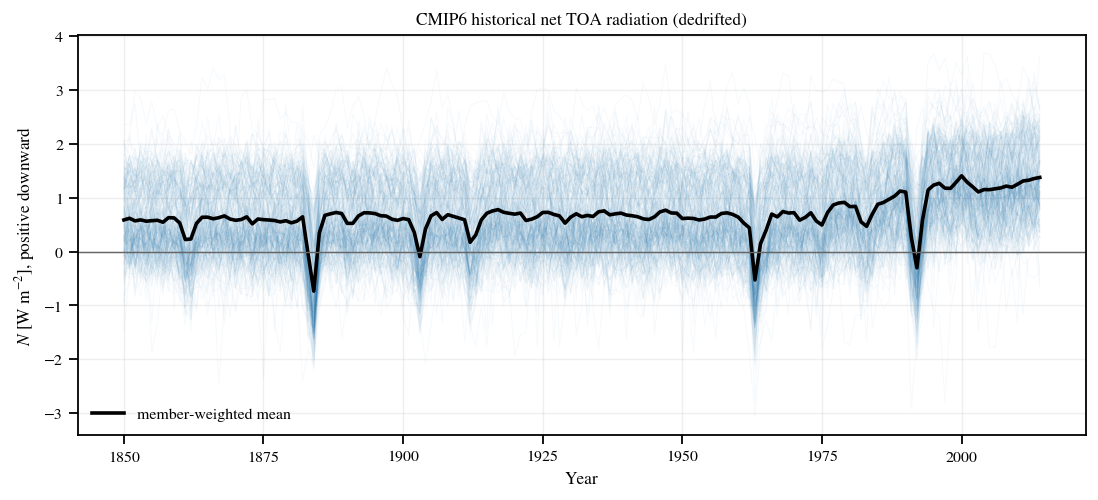

In [8]:
fig, ax = plt.subplots(figsize=(10, 4), dpi=130)
ax.plot(
    net_toa_ds["year"],
    net_toa_ds["net_toa"].transpose("year", "member"),
    color="tab:blue",
    alpha=0.035,
    lw=0.6,
)
ax.plot(
    net_toa_ds["year"],
    net_toa_ds["net_toa"].mean("member"),
    color="black",
    lw=2,
    label="member-weighted mean",
)
ax.axhline(0, color="0.4", lw=0.8)
ax.set(
    title=f"CMIP6 historical net TOA radiation ({DATA_PRODUCT})",
    xlabel="Year",
    ylabel=r"$N$ [W m$^{-2}$], positive downward",
)
ax.grid(alpha=0.2)
ax.legend(frameon=False)
plt.show()

## Exploratory 1850–1900 spread

The member-weighted distribution strongly overweights models with large ensembles. Therefore the notebook also averages members within each `source_id` before calculating an equal-model spread. Both are shown; the equal-model summary is generally the more defensible inter-model comparison.

In [9]:
pi_period = slice(1850, 1900)
pi_member_mean = net_toa_ds["net_toa"].sel(year=pi_period).mean("year")

pi_members = pd.DataFrame(
    {
        "member": net_toa_ds["member"].values,
        "institution": net_toa_ds["institution"].values,
        "source_id": net_toa_ds["source_id"].values,
        "variant_label": net_toa_ds["variant_label"].values,
        "net_toa_1850_1900": pi_member_mean.values,
    }
)
pi_models = (
    pi_members.groupby("source_id", as_index=False)
    .agg(
        net_toa_1850_1900=("net_toa_1850_1900", "mean"),
        n_members=("member", "size"),
    )
)

def spread_summary(values):
    values = np.asarray(values, dtype=float)
    quantiles = np.quantile(values, [0.05, 0.17, 0.50, 0.83, 0.95])
    return pd.Series(
        {
            "n": len(values),
            "mean": values.mean(),
            "std (ddof=1)": values.std(ddof=1),
            "p05": quantiles[0],
            "p17": quantiles[1],
            "p50": quantiles[2],
            "p83": quantiles[3],
            "p95": quantiles[4],
        }
    )

pi_spread_summary = pd.DataFrame(
    {
        "ensemble members (member weighted)": spread_summary(
            pi_members["net_toa_1850_1900"]
        ),
        "models (equal source_id weight)": spread_summary(
            pi_models["net_toa_1850_1900"]
        ),
    }
).T
display(pi_spread_summary.round(3))
display(pi_models.sort_values("net_toa_1850_1900"))

,n,mean,std (ddof=1),p05,p17,p50,p83,p95
ensemble members (member weighted),241.0,0.552,0.599,-0.181,0.046,0.285,1.183,1.541
models (equal source_id weight),30.0,0.621,0.716,-0.275,0.039,0.354,1.297,1.840


,source_id,net_toa_1850_1900,n_members
17,GISS-E2-1-G-CC,-0.340529,1
3,BCC-ESM1,-0.327242,3
28,NorESM2-MM,-0.210314,3
1,ACCESS-ESM1-5,-0.152678,10
7,CESM2-WACCM-FV2,-0.046105,3
16,GISS-E2-1-G,0.045372,38
19,HadGEM3-GC31-LL,0.116182,4
6,CESM2-WACCM,0.121200,3
18,GISS-E2-1-H,0.164581,15
20,HadGEM3-GC31-MM,0.184630,4


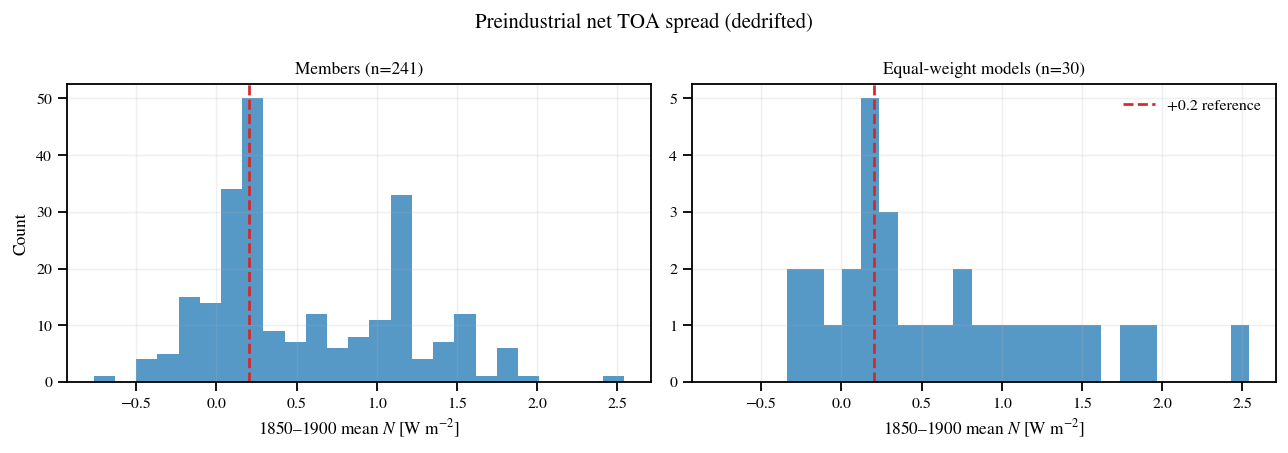

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), dpi=130, sharex=True)
for ax, values, title in [
    (
        axes[0],
        pi_members["net_toa_1850_1900"],
        f"Members (n={len(pi_members)})",
    ),
    (
        axes[1],
        pi_models["net_toa_1850_1900"],
        f"Equal-weight models (n={len(pi_models)})",
    ),
]:
    ax.hist(values, bins=25, color="tab:blue", alpha=0.75)
    ax.axvline(0.2, color="tab:red", ls="--", lw=1.5, label="+0.2 reference")
    ax.set(title=title, xlabel=r"1850–1900 mean $N$ [W m$^{-2}$]")
    ax.grid(alpha=0.2)
axes[0].set_ylabel("Count")
axes[1].legend(frameon=False)
fig.suptitle(f"Preindustrial net TOA spread ({DATA_PRODUCT})")
fig.tight_layout()
plt.show()

### Interpretation warning

The raw cross-model spread is **not automatically an uncertainty distribution for Earth's true preindustrial energy imbalance**. It includes model-specific TOA energy non-closure, control-state drift/spin-up, structural differences, and internal variability. It also depends on model weighting. Compare raw and dedrifted results, inspect control simulations if available, and decide explicitly which components represent uncertainty rather than model bias before using this spread as a prior. The red +0.2 W m$^{-2}$ line above is only a reference value, not evidence that the model distribution and the Sherwood et al. observationally informed assessment estimate the same quantity.

In [11]:
# Optional compact export. Provenance remains in the in-memory table above.
SAVE_NETCDF = False
OUTPUT_FILE = Path(f"cmip6_historical_net_toa_annual_{DATA_PRODUCT}.nc")

if SAVE_NETCDF:
    encoding = {name: {"zlib": True, "complevel": 4} for name in net_toa_ds.data_vars}
    net_toa_ds.to_netcdf(OUTPUT_FILE, encoding=encoding)
    print(f"Saved {OUTPUT_FILE.resolve()}")
else:
    print("SAVE_NETCDF is False; no data file was written.")

SAVE_NETCDF is False; no data file was written.


## Equal-model $\Delta N$ and variance decomposition

For member $r$ of model $m$, define

$$\Delta N_{mr} = \overline{N}_{mr,\,\mathrm{last\ 19\ years}} - \overline{N}_{mr,\,1850\text{–}1900}.$$

With `END_YEAR = 2014`, the final window is 1996–2014 inclusive. The overall estimate and intermodel spread give each `source_id` equal weight, regardless of ensemble size.

For internal variability, members are pooled only when they share the same CMIP6 initialization (`i`), physics (`p`), and forcing (`f`) indices and differ in realization (`r`). This avoids treating perturbed-physics or forcing-index differences as internal variability. The conventional pooled within-configuration variance is

$$s^2_{\mathrm{IV,pool}} = \frac{\sum_g (n_g-1)s_g^2}{\sum_g(n_g-1)},$$

where $g$ indexes model–`i/p/f` groups with at least two realizations. The observed intermodel variance is the sample variance of equal-weight model means. A second, approximate structural intermodel variance subtracts the estimated finite-ensemble sampling variance of those model means.

In [12]:
import re

N_RECENT_YEARS = 19
recent_end = int(net_toa_ds["year"].max())
recent_start = recent_end - N_RECENT_YEARS + 1
baseline_start, baseline_end = 1850, 1900

recent_mean = net_toa_ds["net_toa"].sel(
    year=slice(recent_start, recent_end)
).mean("year")
baseline_mean = net_toa_ds["net_toa"].sel(
    year=slice(baseline_start, baseline_end)
).mean("year")
delta_n_member_da = (recent_mean - baseline_mean).rename("delta_n")

delta_n_members = pd.DataFrame(
    {
        "member": net_toa_ds["member"].values,
        "institution": net_toa_ds["institution"].values,
        "source_id": net_toa_ds["source_id"].values,
        "variant_label": net_toa_ds["variant_label"].values,
        "delta_n": delta_n_member_da.values,
    }
)

variant_parts = delta_n_members["variant_label"].str.extract(
    r"^r(?P<realization>\d+)i(?P<initialization>\d+)"
    r"p(?P<physics>\d+)f(?P<forcing>\d+)$"
)
if variant_parts.isna().any(axis=None):
    bad_labels = delta_n_members.loc[variant_parts.isna().any(axis=1), "variant_label"]
    raise ValueError(f"Could not parse variant labels: {bad_labels.unique()}")
for column in variant_parts:
    delta_n_members[column] = variant_parts[column].astype(int)

# Equal weight is applied after averaging every available member of each source_id.
delta_n_models = (
    delta_n_members.groupby("source_id", as_index=False)
    .agg(
        delta_n=("delta_n", "mean"),
        n_members=("member", "size"),
        member_sd=("delta_n", "std"),
    )
    .sort_values("delta_n")
)

equal_model_delta_n_summary = spread_summary(delta_n_models["delta_n"]).to_frame(
    "equal-model delta N"
).T
print(
    f"Delta N = mean({recent_start}-{recent_end}) - "
    f"mean({baseline_start}-{baseline_end}); product={DATA_PRODUCT}"
)
display(equal_model_delta_n_summary.round(4))
display(delta_n_models.reset_index(drop=True))

Delta N = mean(1996-2014) - mean(1850-1900); product=dedrifted


,n,mean,std (ddof=1),p05,p17,p50,p83,p95
equal-model delta N,30.0,0.6876,0.1277,0.5435,0.5652,0.665,0.7936,0.9451


,source_id,delta_n,n_members,member_sd
0,NorESM2-MM,0.420472,3,0.072388
1,CNRM-CM6-1,0.542616,10,0.043912
2,CNRM-CM6-1-HR,0.544489,1,NaN
3,SAM0-UNICON,0.556874,1,NaN
4,CESM2,0.557046,11,0.051621
5,CNRM-ESM2-1,0.565809,10,0.064939
6,CESM2-FV2,0.589419,3,0.076479
7,MIROC6,0.597667,34,0.054132
8,BCC-ESM1,0.598944,3,0.062632
9,GISS-E2-1-H,0.616465,15,0.041228


In [13]:
config_columns = ["source_id", "initialization", "physics", "forcing"]
config_stats = (
    delta_n_members.groupby(config_columns, as_index=False)
    .agg(
        n=("delta_n", "size"),
        mean_delta_n=("delta_n", "mean"),
        variance=("delta_n", "var"),
    )
)
replicated_configs = config_stats.query("n >= 2").copy()
replicated_configs["df"] = replicated_configs["n"] - 1
replicated_configs["within_ss"] = (
    replicated_configs["df"] * replicated_configs["variance"]
)

within_df = int(replicated_configs["df"].sum())
pooled_internal_variance = replicated_configs["within_ss"].sum() / within_df

# A model-specific pooled estimate supports the equal-model sensitivity estimate.
internal_by_model = (
    replicated_configs.groupby("source_id", as_index=False)
    .agg(within_ss=("within_ss", "sum"), within_df=("df", "sum"))
)
internal_by_model["internal_variance"] = (
    internal_by_model["within_ss"] / internal_by_model["within_df"]
)
equal_model_internal_variance = internal_by_model["internal_variance"].mean()

observed_intermodel_variance = delta_n_models["delta_n"].var(ddof=1)

# Model means retain finite-ensemble internal variability. Use each model's
# estimate where possible and the global pooled value for singleton models.
model_variance_inputs = delta_n_models.merge(
    internal_by_model[["source_id", "internal_variance"]],
    on="source_id",
    how="left",
)
model_variance_inputs["internal_variance_filled"] = model_variance_inputs[
    "internal_variance"
].fillna(pooled_internal_variance)
model_variance_inputs["sampling_variance_of_mean"] = (
    model_variance_inputs["internal_variance_filled"]
    / model_variance_inputs["n_members"]
)
mean_sampling_variance = model_variance_inputs["sampling_variance_of_mean"].mean()
adjusted_intermodel_variance = max(
    0.0, observed_intermodel_variance - mean_sampling_variance
)

variance_components = pd.DataFrame(
    [
        {
            "quantity": "internal variability: conventional pooled within i/p/f",
            "variance": pooled_internal_variance,
            "notes": f"{within_df} within-group df",
        },
        {
            "quantity": "internal variability: equal-model mean of model variances",
            "variance": equal_model_internal_variance,
            "notes": f"{len(internal_by_model)} models with replicated i/p/f groups",
        },
        {
            "quantity": "intermodel: observed variance of equal-weight model means",
            "variance": observed_intermodel_variance,
            "notes": f"{len(delta_n_models)} source_id means",
        },
        {
            "quantity": "internal sampling variance remaining in model means",
            "variance": mean_sampling_variance,
            "notes": "mean estimated Var(model mean)",
        },
        {
            "quantity": "intermodel: adjusted structural variance",
            "variance": adjusted_intermodel_variance,
            "notes": "observed intermodel variance minus finite-ensemble sampling variance",
        },
    ]
).set_index("quantity")
variance_components["standard_deviation"] = np.sqrt(
    variance_components["variance"]
)
variance_components.attrs["variance_units"] = "(W m-2)^2"
variance_components.attrs["standard_deviation_units"] = "W m-2"
display(variance_components.round(5))
display(replicated_configs.sort_values(["source_id", "forcing"]))

,variance,notes,standard_deviation
quantity,,,
internal variability: conventional pooled within i/p/f,0.00329,204 within-group df,0.05736
internal variability: equal-model mean of model variances,0.00350,24 models with replicated i/p/f groups,0.05912
intermodel: observed variance of equal-weight model means,0.01631,30 source_id means,0.12771
internal sampling variance remaining in model means,0.00122,mean estimated Var(model mean),0.03498
intermodel: adjusted structural variance,0.01509,observed intermodel variance minus finite-ensemble sampling variance,0.12282


,source_id,initialization,physics,forcing,n,mean_delta_n,variance,df,within_ss
0,ACCESS-CM2,1,1,1,3,0.740156,0.001120,2,0.002240
1,ACCESS-ESM1-5,1,1,1,10,0.694685,0.004459,9,0.040130
2,AWI-CM-1-1-MR,1,1,1,5,0.724727,0.005152,4,0.020610
3,BCC-ESM1,1,1,1,3,0.598944,0.003923,2,0.007845
4,CESM2,1,1,1,11,0.557046,0.002665,10,0.026648
5,CESM2-FV2,1,1,1,3,0.589419,0.005849,2,0.011698
6,CESM2-WACCM,1,1,1,3,0.702865,0.003582,2,0.007163
7,CESM2-WACCM-FV2,1,1,1,3,0.652684,0.001645,2,0.003289
9,CNRM-CM6-1,1,1,2,10,0.542616,0.001928,9,0.017355
11,CNRM-ESM2-1,1,1,2,10,0.565809,0.004217,9,0.037953


The unadjusted intermodel variance is the directly observed spread requested above. The adjusted value is a method-of-moments estimate: it removes the average estimated internal-variability variance still present in finite ensemble means. This correction assumes members are independent and that within-ensemble variability represents the relevant sampling noise. Models with one member cannot estimate their own internal variance, so the conventional pooled variance is used for their correction.

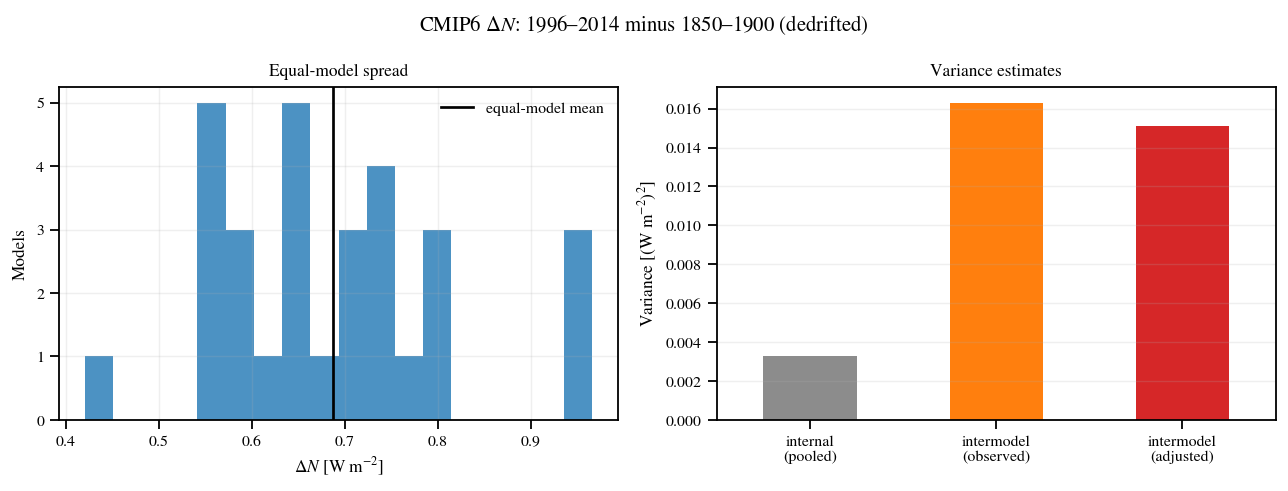

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), dpi=130)

axes[0].hist(delta_n_models["delta_n"], bins=18, color="tab:blue", alpha=0.8)
axes[0].axvline(
    delta_n_models["delta_n"].mean(),
    color="black",
    lw=1.5,
    label="equal-model mean",
)
axes[0].set(
    title="Equal-model spread",
    xlabel=r"$\Delta N$ [W m$^{-2}$]",
    ylabel="Models",
)
axes[0].legend(frameon=False)
axes[0].grid(alpha=0.2)

component_plot = pd.Series(
    {
        "internal\n(pooled)": pooled_internal_variance,
        "intermodel\n(observed)": observed_intermodel_variance,
        "intermodel\n(adjusted)": adjusted_intermodel_variance,
    }
)
component_plot.plot.bar(ax=axes[1], color=["0.55", "tab:orange", "tab:red"])
axes[1].set(
    title="Variance estimates",
    ylabel=r"Variance [(W m$^{-2}$)$^2$]",
    xlabel="",
)
axes[1].tick_params(axis="x", rotation=0)
axes[1].grid(axis="y", alpha=0.2)

fig.suptitle(
    f"CMIP6 $\Delta N$: {recent_start}–{recent_end} minus "
    f"{baseline_start}–{baseline_end} ({DATA_PRODUCT})"
)
fig.tight_layout()
plt.show()

## Ballinger et al. (2026) UKESM1-1-LL historical1750 ensemble

Load the six `historical1750` ensemble members from the GloSAT/Ballinger et al. archive and calculate annual global-mean net TOA radiation,

$$N = rsdt - rsut - rlut.$$

These are monthly gridded NetCDF files on the native N96 atmosphere grid. The files reference external `areacella`, but that field is not present in this directory. Exact spherical cell-area weights are therefore calculated from the supplied latitude and longitude bounds. The 360-day calendar has 12 equal-length months per year.

The primary calculation follows the requested periods literally: mean(1850–1900) minus mean(1750–1850), with both endpoints included. This counts 1850 in both periods. A non-overlapping mean(1850–1900) minus mean(1750–1849) sensitivity is also reported.

In [15]:
BALLINGER_ROOT = Path(
    "/glade/derecho/scratch/vcooper/p2c2/historical/"
    "ballinger2026_ukesm1750/GloSAT_historical1750"
)
BALLINGER_VARIABLES = ("rsdt", "rsut", "rlut")
BALLINGER_LATE_PERIOD = (1850, 1900)
BALLINGER_EARLY_PERIOD = (1750, 1849)  # Literal request; overlaps in 1850.
BALLINGER_EARLY_NONOVERLAP = (1750, 1800)

if not BALLINGER_ROOT.is_dir():
    raise FileNotFoundError(BALLINGER_ROOT)

ballinger_member_dirs = sorted(path for path in BALLINGER_ROOT.iterdir() if path.is_dir())
if len(ballinger_member_dirs) != 6:
    raise ValueError(
        f"Expected 6 Ballinger ensemble members; found {len(ballinger_member_dirs)}"
    )
print("Members:", [path.name for path in ballinger_member_dirs])

Members: ['r1i1p1f2', 'r2i1p1f2', 'r3i1p1f2', 'r4i1p1f2', 'r5i1p1f2', 'r6i1p1f2']


In [16]:
def spherical_cell_area_weights(dataset):
    """Dimensionless spherical cell areas from one-dimensional bounds."""
    required = {"lat_bnds", "lon_bnds"}
    missing = required - set(dataset.variables)
    if missing:
        raise ValueError(f"Missing grid bounds: {sorted(missing)}")

    lat_lower = np.deg2rad(dataset["lat_bnds"].isel(bnds=0))
    lat_upper = np.deg2rad(dataset["lat_bnds"].isel(bnds=1))
    lat_factor = abs(np.sin(lat_upper) - np.sin(lat_lower))

    lon_lower = dataset["lon_bnds"].isel(bnds=0)
    lon_upper = dataset["lon_bnds"].isel(bnds=1)
    lon_width_degrees = abs(lon_upper - lon_lower)
    lon_factor = np.deg2rad(lon_width_degrees)

    weights = (lat_factor * lon_factor).rename("cell_area_weight")
    if not bool((weights > 0).all()):
        raise ValueError("Non-positive spherical cell-area weight")
    np.testing.assert_allclose(float(weights.sum()), 4 * np.pi, rtol=1e-10)
    return weights


def load_annual_global_mean(files, variable):
    """Area-average monthly files, then return complete annual means."""
    files = sorted(Path(path) for path in files)
    if not files:
        raise FileNotFoundError(f"No {variable} files")

    annual_segments = []
    for path in files:
        with xr.open_dataset(path, decode_times=True) as dataset:
            if variable not in dataset:
                raise KeyError(f"{variable} is absent from {path}")
            if dataset["time"].encoding.get("calendar") != "360_day":
                raise ValueError(f"Unexpected calendar in {path}")
            if dataset[variable].attrs.get("units") != "W m-2":
                raise ValueError(f"Unexpected units in {path}")

            weights = spherical_cell_area_weights(dataset)
            monthly_global = (
                dataset[variable]
                .weighted(weights)
                .mean(("lat", "lon"))
                .load()
            )
            months_per_year = monthly_global.groupby("time.year").count()
            if not bool((months_per_year == 12).all()):
                raise ValueError(f"Incomplete year in {path}")
            annual_segments.append(
                monthly_global.groupby("time.year").mean("time")
            )

    annual = xr.concat(annual_segments, dim="year").sortby("year")
    years = annual["year"].to_numpy().astype(int)
    if len(np.unique(years)) != len(years):
        raise ValueError(f"Duplicate years after combining {variable} segments")
    np.testing.assert_array_equal(years, np.arange(years.min(), years.max() + 1))
    annual.name = variable
    annual.attrs.update({"units": "W m-2", "spatial_mean": "global area weighted"})
    return annual


def load_ballinger_ensemble(root):
    member_datasets = []
    provenance_rows = []

    for member_dir in sorted(path for path in root.iterdir() if path.is_dir()):
        member = member_dir.name
        annual_fluxes = {}
        source_files = {}
        for variable in BALLINGER_VARIABLES:
            files = sorted((member_dir / variable).glob("*.nc"))
            if len(files) != 3:
                raise ValueError(
                    f"Expected 3 {variable} segments for {member}; found {len(files)}"
                )
            annual_fluxes[variable] = load_annual_global_mean(files, variable)
            source_files[variable] = " | ".join(str(path) for path in files)

        member_dataset = xr.Dataset(annual_fluxes)
        member_dataset["net_toa"] = (
            member_dataset["rsdt"]
            - member_dataset["rsut"]
            - member_dataset["rlut"]
        )
        member_dataset["net_toa"].attrs.update(
            {
                "long_name": "Net top-of-atmosphere downward radiative flux",
                "formula": "rsdt - rsut - rlut",
                "positive": "down",
                "units": "W m-2",
            }
        )
        member_datasets.append(member_dataset.expand_dims(member=[member]))
        provenance_rows.append({"member": member, **source_files})
        print(f"Loaded {member}")

    ensemble = xr.concat(member_datasets, dim="member", join="exact")
    ensemble.attrs.update(
        {
            "source": "Ballinger et al. (2026) GloSAT historical1750",
            "source_id": "UKESM1-1-LL",
            "source_directory": str(root),
        }
    )
    provenance = pd.DataFrame(provenance_rows).set_index("member")
    return ensemble, provenance

In [17]:
ballinger_ds, ballinger_provenance = load_ballinger_ensemble(BALLINGER_ROOT)

np.testing.assert_array_equal(ballinger_ds["year"], np.arange(1750, 2015))
assert ballinger_ds.sizes == {"member": 6, "year": 265}
assert np.isfinite(ballinger_ds.to_array()).all()
ballinger_identity_error = abs(
    ballinger_ds["net_toa"]
    - (ballinger_ds["rsdt"] - ballinger_ds["rsut"] - ballinger_ds["rlut"])
).max().item()
assert ballinger_identity_error < 1e-10

print(ballinger_ds)
print(f"Maximum formula identity error: {ballinger_identity_error:.3g} W m-2")
display(ballinger_provenance)

Loaded r1i1p1f2


Loaded r2i1p1f2


Loaded r3i1p1f2


Loaded r4i1p1f2


Loaded r5i1p1f2


Loaded r6i1p1f2
<xarray.Dataset> Size: 53kB
Dimensions:  (member: 6, year: 265)
Coordinates:
  * member   (member) object 48B 'r1i1p1f2' 'r2i1p1f2' ... 'r5i1p1f2' 'r6i1p1f2'
  * year     (year) int64 2kB 1750 1751 1752 1753 1754 ... 2011 2012 2013 2014
Data variables:
    rsdt     (member, year) float64 13kB 340.5 340.5 340.4 ... 340.4 340.4 340.5
    rsut     (member, year) float64 13kB 98.1 98.13 97.89 ... 97.8 97.79 97.17
    rlut     (member, year) float64 13kB 242.4 242.2 242.4 ... 241.6 241.4 241.8
    net_toa  (member, year) float64 13kB 0.02023 0.1616 0.1072 ... 1.258 1.441
Attributes:
    source:            Ballinger et al. (2026) GloSAT historical1750
    source_id:         UKESM1-1-LL
    source_directory:  /glade/derecho/scratch/vcooper/p2c2/historical/balling...
Maximum formula identity error: 0 W m-2


,rsdt,rsut,rlut
member,,,
r1i1p1f2,/glade/derecho/scratch/vcooper/p2c2/historical/ballinger2026_ukesm1750/GloSAT_historical1750/r1i1p1f2/rsdt/rsdt_Amon...,/glade/derecho/scratch/vcooper/p2c2/historical/ballinger2026_ukesm1750/GloSAT_historical1750/r1i1p1f2/rsut/rsut_Amon...,/glade/derecho/scratch/vcooper/p2c2/historical/ballinger2026_ukesm1750/GloSAT_historical1750/r1i1p1f2/rlut/rlut_Amon...
r2i1p1f2,/glade/derecho/scratch/vcooper/p2c2/historical/ballinger2026_ukesm1750/GloSAT_historical1750/r2i1p1f2/rsdt/rsdt_Amon...,/glade/derecho/scratch/vcooper/p2c2/historical/ballinger2026_ukesm1750/GloSAT_historical1750/r2i1p1f2/rsut/rsut_Amon...,/glade/derecho/scratch/vcooper/p2c2/historical/ballinger2026_ukesm1750/GloSAT_historical1750/r2i1p1f2/rlut/rlut_Amon...
r3i1p1f2,/glade/derecho/scratch/vcooper/p2c2/historical/ballinger2026_ukesm1750/GloSAT_historical1750/r3i1p1f2/rsdt/rsdt_Amon...,/glade/derecho/scratch/vcooper/p2c2/historical/ballinger2026_ukesm1750/GloSAT_historical1750/r3i1p1f2/rsut/rsut_Amon...,/glade/derecho/scratch/vcooper/p2c2/historical/ballinger2026_ukesm1750/GloSAT_historical1750/r3i1p1f2/rlut/rlut_Amon...
r4i1p1f2,/glade/derecho/scratch/vcooper/p2c2/historical/ballinger2026_ukesm1750/GloSAT_historical1750/r4i1p1f2/rsdt/rsdt_Amon...,/glade/derecho/scratch/vcooper/p2c2/historical/ballinger2026_ukesm1750/GloSAT_historical1750/r4i1p1f2/rsut/rsut_Amon...,/glade/derecho/scratch/vcooper/p2c2/historical/ballinger2026_ukesm1750/GloSAT_historical1750/r4i1p1f2/rlut/rlut_Amon...
r5i1p1f2,/glade/derecho/scratch/vcooper/p2c2/historical/ballinger2026_ukesm1750/GloSAT_historical1750/r5i1p1f2/rsdt/rsdt_Amon...,/glade/derecho/scratch/vcooper/p2c2/historical/ballinger2026_ukesm1750/GloSAT_historical1750/r5i1p1f2/rsut/rsut_Amon...,/glade/derecho/scratch/vcooper/p2c2/historical/ballinger2026_ukesm1750/GloSAT_historical1750/r5i1p1f2/rlut/rlut_Amon...
r6i1p1f2,/glade/derecho/scratch/vcooper/p2c2/historical/ballinger2026_ukesm1750/GloSAT_historical1750/r6i1p1f2/rsdt/rsdt_Amon...,/glade/derecho/scratch/vcooper/p2c2/historical/ballinger2026_ukesm1750/GloSAT_historical1750/r6i1p1f2/rsut/rsut_Amon...,/glade/derecho/scratch/vcooper/p2c2/historical/ballinger2026_ukesm1750/GloSAT_historical1750/r6i1p1f2/rlut/rlut_Amon...


In [18]:
def annual_period_mean(data_array, period):
    start, end = period
    selected = data_array.sel(year=slice(start, end))
    expected_n_years = end - start + 1
    if selected.sizes["year"] != expected_n_years:
        raise ValueError(f"Incomplete period {start}-{end}")
    return selected.mean("year")


ballinger_late_mean = annual_period_mean(
    ballinger_ds["net_toa"], BALLINGER_LATE_PERIOD
)
ballinger_early_mean = annual_period_mean(
    ballinger_ds["net_toa"], BALLINGER_EARLY_PERIOD
)
ballinger_early_nonoverlap_mean = annual_period_mean(
    ballinger_ds["net_toa"], BALLINGER_EARLY_NONOVERLAP
)
ballinger_delta_eei = (ballinger_late_mean - ballinger_early_mean).rename(
    "delta_eei_literal"
)
ballinger_delta_eei_nonoverlap = (
    ballinger_late_mean - ballinger_early_nonoverlap_mean
).rename("delta_eei_nonoverlap")

ballinger_member_periods = pd.DataFrame(
    {
        "member": ballinger_ds["member"].values,
        "mean_N_1750_1850": ballinger_early_mean.values,
        "mean_N_1750_1849": ballinger_early_nonoverlap_mean.values,
        "mean_N_1850_1900": ballinger_late_mean.values,
        "delta_N_literal": ballinger_delta_eei.values,
        "delta_N_nonoverlap": ballinger_delta_eei_nonoverlap.values,
    }
)

def small_ensemble_summary(values):
    values = np.asarray(values, dtype=float)
    quantiles = np.quantile(values, [0.05, 0.17, 0.50, 0.83, 0.95])
    return pd.Series(
        {
            "n": len(values),
            "mean": values.mean(),
            "variance (ddof=1)": values.var(ddof=1),
            "std (ddof=1)": values.std(ddof=1),
            "min": values.min(),
            "p05": quantiles[0],
            "p17": quantiles[1],
            "p50": quantiles[2],
            "p83": quantiles[3],
            "p95": quantiles[4],
            "max": values.max(),
        }
    )

ballinger_delta_summary = pd.DataFrame(
    {
        "1850-1900 minus 1750-1850 (literal)": small_ensemble_summary(
            ballinger_delta_eei.values
        ),
        "1850-1900 minus 1750-1849 (non-overlap)": small_ensemble_summary(
            ballinger_delta_eei_nonoverlap.values
        ),
    }
).T
ballinger_delta_summary.attrs["units"] = "W m-2"

display(ballinger_member_periods.round(5))
display(ballinger_delta_summary.round(5))
print("With only six members, empirical tail percentiles are descriptive, not robust.")

,member,mean_N_1750_1850,mean_N_1750_1849,mean_N_1850_1900,delta_N_literal,delta_N_nonoverlap
0,r1i1p1f2,-0.01437,0.04452,0.09779,0.11216,0.05327
1,r2i1p1f2,0.02666,0.05859,0.06318,0.03652,0.00459
2,r3i1p1f2,0.03024,0.05979,0.10099,0.07076,0.04121
3,r4i1p1f2,0.00420,0.08271,0.07916,0.07496,-0.00355
4,r5i1p1f2,-0.00136,0.01691,0.12696,0.12832,0.11005
5,r6i1p1f2,0.00714,0.03530,0.07771,0.07057,0.04241


,n,mean,variance (ddof=1),std (ddof=1),min,p05,p17,p50,p83,p95,max
1850-1900 minus 1750-1850 (literal),6.0,0.08221,0.00109,0.03295,0.03652,0.04503,0.06546,0.07286,0.11458,0.12428,0.12832
1850-1900 minus 1750-1849 (non-overlap),6.0,0.04133,0.00165,0.04057,-0.00355,-0.00151,0.00337,0.04181,0.06178,0.09586,0.11005


With only six members, empirical tail percentiles are descriptive, not robust.


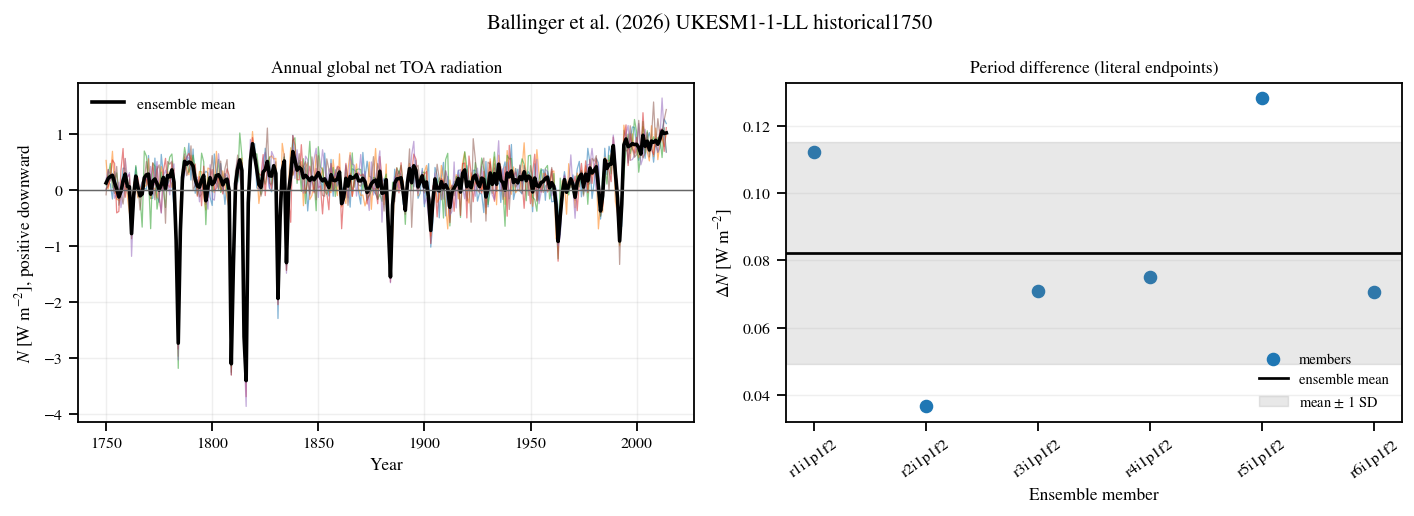

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), dpi=130)

for member in ballinger_ds["member"].values:
    axes[0].plot(
        ballinger_ds["year"],
        ballinger_ds["net_toa"].sel(member=member),
        lw=0.7,
        alpha=0.55,
    )
axes[0].plot(
    ballinger_ds["year"],
    ballinger_ds["net_toa"].mean("member"),
    color="black",
    lw=2,
    label="ensemble mean",
)
axes[0].axhline(0, color="0.4", lw=0.8)
axes[0].set(
    title="Annual global net TOA radiation",
    xlabel="Year",
    ylabel=r"$N$ [W m$^{-2}$], positive downward",
)
axes[0].grid(alpha=0.2)
axes[0].legend(frameon=False)

members_x = np.arange(ballinger_ds.sizes["member"])
axes[1].scatter(
    members_x,
    ballinger_delta_eei,
    s=45,
    color="tab:blue",
    label="members",
)
delta_mean = float(ballinger_delta_eei.mean())
delta_sd = float(ballinger_delta_eei.std(ddof=1))
axes[1].axhline(delta_mean, color="black", lw=1.5, label="ensemble mean")
axes[1].axhspan(
    delta_mean - delta_sd,
    delta_mean + delta_sd,
    color="0.5",
    alpha=0.18,
    label=r"mean $\pm$ 1 SD",
)
axes[1].set(
    title="Period difference (literal endpoints)",
    xlabel="Ensemble member",
    ylabel=r"$\Delta N$ [W m$^{-2}$]",
    xticks=members_x,
    xticklabels=ballinger_ds["member"].values,
)
axes[1].tick_params(axis="x", rotation=35)
axes[1].grid(axis="y", alpha=0.2)
axes[1].legend(frameon=False, fontsize=8)

fig.suptitle("Ballinger et al. (2026) UKESM1-1-LL historical1750")
fig.tight_layout()
plt.show()

In [20]:
print((ballinger_ds["net_toa"].sel(year=slice(2006,2014)).mean(dim='year') - ballinger_ds["net_toa"].sel(year=slice(1850,1900)).mean(dim='year')).mean())

print((ballinger_ds["net_toa"].sel(year=slice(2006,2014)).mean(dim='year') - ballinger_ds["net_toa"].sel(year=slice(1750,1800)).mean(dim='year')).mean())

<xarray.DataArray 'net_toa' ()> Size: 8B
array(0.81712301)
<xarray.DataArray 'net_toa' ()> Size: 8B
array(0.85845203)


## Myhre et al. (2025) Fig. 3B-style CMIP6 trends: historical + SSP2-4.5

This section recreates the model-data structure of [Myhre et al. (2025), Fig. 3B](https://doi.org/10.1126/science.adt0647), but uses the configurable interval below and SSP2-4.5 rather than SSP5-8.5. The plotted components use the paper's positive-downward EEI convention:

- shortwave EEI: $SW = rsdt-rsut$;
- longwave EEI: $LW = -rlut$; and
- net EEI: $N = SW+LW = rsdt-rsut-rlut$.

Ordinary least-squares trends are fitted to the configured annual global means and reported per decade. Historical and SSP2-4.5 records must have an exact `(institution, source_id, variant_label)` match and complete `rsdt`, `rsut`, and `rlut`. Each series is explicitly stitched from historical through 2014 and SSP2-4.5 from 2015. One processing version is selected within each segment, and the exact member match prevents different ensemble realizations from being joined across the boundary.

Each point is the equal-member mean for one `source_id`; horizontal and vertical bars span the minimum to maximum member trend. With few members, these full ranges are descriptive rather than confidence intervals.

In [25]:
DATA_PRODUCT

'dedrifted'

In [26]:
CMIP6_ARCHIVE_ROOT = CMIP_ROOT.parent
TREND_HIST_ROOT = CMIP6_ARCHIVE_ROOT / "CMIP"
TREND_SSP245_ROOT = CMIP6_ARCHIVE_ROOT / "ScenarioMIP"

# Inherit the notebook-wide choice. Replace DATA_PRODUCT below with "raw"
# or "dedrifted" to make this analysis use a different product independently.
TREND_DATA_PRODUCT = 'raw' # 'dedrifted' #DATA_PRODUCT
TREND_PREFIX = PRODUCT_PREFIX[TREND_DATA_PRODUCT]
TREND_VARIABLES = ("rsdt", "rsut", "rlut")

# Change only these endpoints to refit a different interval (e.g., 2003-2024).
TREND_START_YEAR = 2003
TREND_END_YEAR = 2022
HISTORICAL_END_YEAR = 2014
if not TREND_START_YEAR <= HISTORICAL_END_YEAR < TREND_END_YEAR:
    raise ValueError("The configured interval must span the historical/SSP boundary")
TREND_YEARS = np.arange(TREND_START_YEAR, TREND_END_YEAR + 1)
TREND_HIST_YEARS = np.arange(TREND_START_YEAR, HISTORICAL_END_YEAR + 1)
TREND_SSP_YEARS = np.arange(HISTORICAL_END_YEAR + 1, TREND_END_YEAR + 1)

if TREND_DATA_PRODUCT not in PRODUCT_PREFIX:
    raise ValueError(f"Unknown trend product: {TREND_DATA_PRODUCT}")
for archive_path in (TREND_HIST_ROOT, TREND_SSP245_ROOT):
    if not archive_path.is_dir():
        raise FileNotFoundError(archive_path)

print(f"Trend product: {TREND_DATA_PRODUCT!r}")
print(f"Years: {TREND_YEARS[0]}-{TREND_YEARS[-1]} ({len(TREND_YEARS)} annual values)")
print(f"Experiment boundary: historical through {HISTORICAL_END_YEAR}; "
      f"SSP2-4.5 from {HISTORICAL_END_YEAR + 1}")

Trend product: 'raw'
Years: 2003-2022 (20 annual values)
Experiment boundary: historical through 2014; SSP2-4.5 from 2015


In [27]:
def discover_experiment_files(activity_root, experiment_id, prefix):
    """Map exact CMIP6 member identities to variable files."""
    grouped = defaultdict(lambda: defaultdict(list))
    for variable in TREND_VARIABLES:
        pattern = (
            f"*/*/{experiment_id}/*/Amon/{variable}/*/*/"
            f"{prefix}{variable}_*.MAG"
        )
        for path in activity_root.glob(pattern):
            relative = path.relative_to(activity_root).parts
            if len(relative) != 9:
                continue
            (
                institution, source_id, found_experiment, variant_label,
                table_id, found_variable, grid_label, version, filename,
            ) = relative
            if found_experiment == experiment_id and found_variable == variable:
                grouped[(institution, source_id, variant_label)][variable].append(path)
    return grouped


def complete_triplet_keys(grouped):
    required = set(TREND_VARIABLES)
    return {key for key, by_variable in grouped.items() if set(by_variable) == required}


def choose_continuous_magicc_product(paths, required_years):
    """Choose one file that alone covers every required year.

    Newer version labels win; the native grid wins version ties. Selecting
    one file per experiment segment avoids mixing processing versions.
    """
    required_years = pd.Index(required_years, name="year")
    candidates = []
    for path in paths:
        series = read_magicc_world(path)
        window = series.reindex(required_years)
        if np.isfinite(window.to_numpy()).all():
            candidates.append(
                (path.parent.name, int(path.parent.parent.name == "gn"), str(path), window)
            )

    if not candidates:
        return None, None
    version, native_grid, path_string, window = max(
        candidates, key=lambda item: item[:3]
    )
    return window.astype(float), Path(path_string)


def build_ssp245_trend_dataset():
    # Raw products define the universe so missing dedrifted products remain visible.
    raw_hist = discover_experiment_files(
        TREND_HIST_ROOT, "historical", PRODUCT_PREFIX["raw"]
    )
    raw_ssp = discover_experiment_files(
        TREND_SSP245_ROOT, "ssp245", PRODUCT_PREFIX["raw"]
    )
    product_hist = discover_experiment_files(
        TREND_HIST_ROOT, "historical", TREND_PREFIX
    )
    product_ssp = discover_experiment_files(
        TREND_SSP245_ROOT, "ssp245", TREND_PREFIX
    )

    candidate_keys = sorted(
        complete_triplet_keys(raw_hist) & complete_triplet_keys(raw_ssp)
    )
    member_frames = []
    provenance_rows = []
    rejected_rows = []

    for institution, source_id, variant_label in candidate_keys:
        key = (institution, source_id, variant_label)
        member = "/".join(key)
        missing = []
        for experiment, files in (("historical", product_hist), ("ssp245", product_ssp)):
            missing_variables = sorted(
                set(TREND_VARIABLES) - set(files.get(key, {}))
            )
            if missing_variables:
                missing.append(f"{experiment}: {', '.join(missing_variables)}")
        if missing:
            rejected_rows.append(
                {"member": member, "primary_reason": f"missing {TREND_DATA_PRODUCT} product",
                 "details": "; ".join(missing)}
            )
            continue

        frame = pd.DataFrame(index=pd.Index(TREND_YEARS, name="year"))
        paths = {}
        coverage_failures = []
        for variable in TREND_VARIABLES:
            historical, historical_path = choose_continuous_magicc_product(
                product_hist[key][variable], TREND_HIST_YEARS
            )
            scenario, scenario_path = choose_continuous_magicc_product(
                product_ssp[key][variable], TREND_SSP_YEARS
            )
            if historical is None:
                coverage_failures.append(f"historical {variable}")
            if scenario is None:
                coverage_failures.append(f"ssp245 {variable}")
            if historical is None or scenario is None:
                continue

            # Stitch the same CMIP6 member at the official 2014/2015 boundary.
            frame.loc[TREND_HIST_YEARS, variable] = historical.to_numpy()
            frame.loc[TREND_SSP_YEARS, variable] = scenario.to_numpy()
            paths[f"historical_{variable}_file"] = str(historical_path)
            paths[f"ssp245_{variable}_file"] = str(scenario_path)

        if coverage_failures:
            rejected_rows.append(
                {"member": member, "primary_reason": "incomplete required coverage",
                 "details": ", ".join(coverage_failures)}
            )
            continue

        frame["sw_eei"] = frame["rsdt"] - frame["rsut"]
        frame["lw_eei"] = -frame["rlut"]
        frame["net_toa"] = frame["sw_eei"] + frame["lw_eei"]
        member_frames.append((member, frame))
        provenance_rows.append(
            {
                "member": member, "institution": institution,
                "source_id": source_id, "variant_label": variant_label,
                **paths,
            }
        )

    if not member_frames:
        raise RuntimeError("No exactly matched historical + SSP2-4.5 members passed")

    member_ids = np.array([member for member, frame in member_frames], dtype=str)
    data_variables = {
        variable: (("member", "year"), np.stack([frame[variable].to_numpy()
                                                        for member, frame in member_frames]))
        for variable in (*TREND_VARIABLES, "sw_eei", "lw_eei", "net_toa")
    }
    dataset = xr.Dataset(
        data_variables, coords={"member": member_ids, "year": TREND_YEARS}
    )
    provenance = pd.DataFrame(provenance_rows).set_index("member").loc[member_ids]
    rejected = pd.DataFrame(rejected_rows)
    for coordinate in ("institution", "source_id", "variant_label"):
        dataset = dataset.assign_coords(
            {coordinate: ("member", provenance[coordinate].to_numpy(dtype=str))}
        )
    for variable in dataset.data_vars:
        dataset[variable].attrs["units"] = "W m-2"
    dataset["sw_eei"].attrs.update({"formula": "rsdt - rsut", "positive": "down"})
    dataset["lw_eei"].attrs.update({"formula": "-rlut", "positive": "down"})
    dataset["net_toa"].attrs.update(
        {"formula": "rsdt - rsut - rlut", "positive": "down"}
    )
    dataset.attrs.update(
        {"experiment": "historical + ssp245",
         "years": f"{TREND_START_YEAR}-{TREND_END_YEAR}",
         "product": TREND_DATA_PRODUCT,
         "member_match": "exact institution/source_id/variant_label",
         "time_series_source": "matched historical through 2014 + ssp245 from 2015"}
    )
    return dataset, provenance, rejected, len(candidate_keys)

In [28]:
ssp245_trend_ds, ssp245_trend_provenance, ssp245_trend_rejected, trend_candidate_count = (
    build_ssp245_trend_dataset()
)

np.testing.assert_array_equal(ssp245_trend_ds["year"], TREND_YEARS)
assert np.isfinite(ssp245_trend_ds.to_array().values).all()
component_identity_error = abs(
    ssp245_trend_ds["net_toa"]
    - (ssp245_trend_ds["rsdt"] - ssp245_trend_ds["rsut"] - ssp245_trend_ds["rlut"])
).max().item()
assert component_identity_error < 1e-10

trend_selection_summary = pd.Series(
    {
        "raw exact-match candidates": trend_candidate_count,
        f"included {TREND_DATA_PRODUCT} members": ssp245_trend_ds.sizes["member"],
        "included source_id models": np.unique(ssp245_trend_ds["source_id"]).size,
        "rejected candidates": len(ssp245_trend_rejected),
    }, name="count"
)
display(trend_selection_summary.to_frame())
display(ssp245_trend_rejected["primary_reason"].value_counts().rename("count").to_frame())

print("Each time series uses an exact institution/source_id/variant_label match:")
print("standalone historical through 2014, followed by SSP2-4.5 from 2015.")
print(f"Maximum radiation-component identity error: {component_identity_error:.3g} W m-2")

stitch_jumps = (
    ssp245_trend_ds[["sw_eei", "lw_eei", "net_toa"]].sel(
        year=HISTORICAL_END_YEAR + 1
    )
    - ssp245_trend_ds[["sw_eei", "lw_eei", "net_toa"]].sel(
        year=HISTORICAL_END_YEAR
    )
).to_dataframe()[["sw_eei", "lw_eei", "net_toa"]]
display(stitch_jumps.abs().describe().loc[["mean", "50%", "max"]])
ssp245_trend_ds

,count
raw exact-match candidates,218
included raw members,211
included source_id models,30
rejected candidates,7


,count
primary_reason,
incomplete required coverage,7


Each time series uses an exact institution/source_id/variant_label match:
standalone historical through 2014, followed by SSP2-4.5 from 2015.
Maximum radiation-component identity error: 0 W m-2


,sw_eei,lw_eei,net_toa
mean,0.291181,0.265919,0.388016
50%,0.237400,0.228000,0.322000
max,1.208400,1.500000,1.624000


<xarray.Dataset> Size: 274kB
Dimensions:        (member: 211, year: 20)
Coordinates:
  * member         (member) <U42 35kB 'AWI/AWI-CM-1-1-MR/r1i1p1f1' ... 'THU/C...
  * year           (year) int64 160B 2003 2004 2005 2006 ... 2019 2020 2021 2022
    institution    (member) <U19 16kB 'AWI' 'BCC' 'CAMS' ... 'NUIST' 'THU'
    source_id      (member) <U15 13kB 'AWI-CM-1-1-MR' 'BCC-CSM2-MR' ... 'CIESM'
    variant_label  (member) <U9 8kB 'r1i1p1f1' 'r1i1p1f1' ... 'r1i1p1f1'
Data variables:
    rsdt           (member, year) float64 34kB 340.4 340.3 340.3 ... 340.3 340.4
    rsut           (member, year) float64 34kB 98.43 98.24 98.6 ... 95.49 95.38
    rlut           (member, year) float64 34kB 241.1 241.4 240.6 ... 241.0 241.1
    sw_eei         (member, year) float64 34kB 241.9 242.1 241.7 ... 244.8 245.0
    lw_eei         (member, year) float64 34kB -241.1 -241.4 ... -241.0 -241.1
    net_toa        (member, year) float64 34kB 0.8164 0.7318 ... 3.812 3.848
Attributes:
    experiment:          historical + ssp245
    years:               2003-2022
    product:             raw
    member_match:        exact institution/source_id/variant_label
    time_series_source:  matched historical through 2014 + ssp245 from 2015

In [29]:
def ols_trend_per_decade(years, values):
    """OLS slope for annual values, converted from per year to per decade."""
    years = np.asarray(years, dtype=float)
    values = np.asarray(values, dtype=float)
    return float(np.polyfit(years - years.mean(), values, 1)[0] * 10.0)


trend_member_rows = []
for member in ssp245_trend_ds["member"].values:
    member_data = ssp245_trend_ds.sel(member=member)
    trend_member_rows.append(
        {
            "member": str(member),
            "institution": str(member_data["institution"].item()),
            "source_id": str(member_data["source_id"].item()),
            "variant_label": str(member_data["variant_label"].item()),
            "SW trend": ols_trend_per_decade(TREND_YEARS, member_data["sw_eei"]),
            "LW trend": ols_trend_per_decade(TREND_YEARS, member_data["lw_eei"]),
            "net trend": ols_trend_per_decade(TREND_YEARS, member_data["net_toa"]),
        }
    )
trend_member_table = pd.DataFrame(trend_member_rows).set_index("member")
assert np.allclose(
    trend_member_table["net trend"],
    trend_member_table["SW trend"] + trend_member_table["LW trend"],
)

model_trend_summary = (
    trend_member_table.groupby("source_id", sort=True)
    .agg(
        institutions=("institution", lambda x: ", ".join(sorted(set(x)))),
        n_members=("variant_label", "size"),
        SW_mean=("SW trend", "mean"),
        SW_min=("SW trend", "min"),
        SW_max=("SW trend", "max"),
        LW_mean=("LW trend", "mean"),
        LW_min=("LW trend", "min"),
        LW_max=("LW trend", "max"),
        net_mean=("net trend", "mean"),
        net_min=("net trend", "min"),
        net_max=("net trend", "max"),
    )
)
assert np.allclose(model_trend_summary["net_mean"],
                   model_trend_summary["SW_mean"] + model_trend_summary["LW_mean"])
model_trend_summary.insert(0, "plot_number", np.arange(1, len(model_trend_summary) + 1))
model_mean_correlation = model_trend_summary[["LW_mean", "SW_mean"]].corr().iloc[0, 1]
print(f"Intermodel Pearson r (model-mean LW vs SW trends): {model_mean_correlation:.3f}")
display(model_trend_summary.round(3))

Intermodel Pearson r (model-mean LW vs SW trends): -0.952


,plot_number,institutions,n_members,SW_mean,SW_min,SW_max,LW_mean,LW_min,LW_max,net_mean,net_min,net_max
source_id,,,,,,,,,,,,
ACCESS-CM2,1,CSIRO-ARCCSS,3,0.814,0.632,0.926,-0.527,-0.710,-0.247,0.287,0.175,0.385
ACCESS-ESM1-5,2,CSIRO,3,0.662,0.499,0.774,-0.326,-0.487,-0.029,0.336,0.250,0.469
AWI-CM-1-1-MR,3,AWI,1,0.370,0.370,0.370,-0.132,-0.132,-0.132,0.238,0.238,0.238
BCC-CSM2-MR,4,BCC,1,0.285,0.285,0.285,-0.145,-0.145,-0.145,0.140,0.140,0.140
CAMS-CSM1-0,5,CAMS,2,0.088,0.028,0.149,0.025,0.025,0.026,0.114,0.053,0.174
CESM2,6,NCAR,3,0.338,0.207,0.498,-0.132,-0.362,0.019,0.207,0.136,0.328
CESM2-WACCM,7,NCAR,3,0.275,0.170,0.395,-0.203,-0.219,-0.188,0.072,-0.050,0.195
CIESM,8,THU,1,0.767,0.767,0.767,-0.443,-0.443,-0.443,0.325,0.325,0.325
CMCC-CM2-SR5,9,CMCC,1,-0.308,-0.308,-0.308,0.220,0.220,0.220,-0.088,-0.088,-0.088


In [30]:
ceresdf = pd.DataFrame({
    "method": [
        "Original / observed",
        "Original / observed",
        "Original / observed",
        "CRK / residual-adjusted",
        "CRK / residual-adjusted",
        "CRK / residual-adjusted",
    ],
    "component": [
        "SW",
        "LW",
        "Net",
        "SW",
        "LW",
        "Net",
    ],
    "trend_W_m2_decade": [
        0.672,
        -0.261,
        0.457,
        0.672 - 0.275,
        -0.261 + 0.236,
        0.457 - 0.039,
        # 0.450,
        # -0.040,
        # 0.410,
    ],
    "error_W_m2_decade": [
        0.105,
        0.109,
        0.130,
        0.105,
        0.109,
        0.130,
    ],
    "period": [
        "2003–2022",
        "2003–2022",
        "2003–2022",
        "2003–2022",
        "2003–2022",
        "2003–2022",
    ],
})

ceresdf

,method,component,trend_W_m2_decade,error_W_m2_decade,period
0,Original / observed,SW,0.672,0.105,2003–2022
1,Original / observed,LW,-0.261,0.109,2003–2022
2,Original / observed,Net,0.457,0.130,2003–2022
3,CRK / residual-adjusted,SW,0.397,0.105,2003–2022
4,CRK / residual-adjusted,LW,-0.025,0.109,2003–2022
5,CRK / residual-adjusted,Net,0.418,0.130,2003–2022


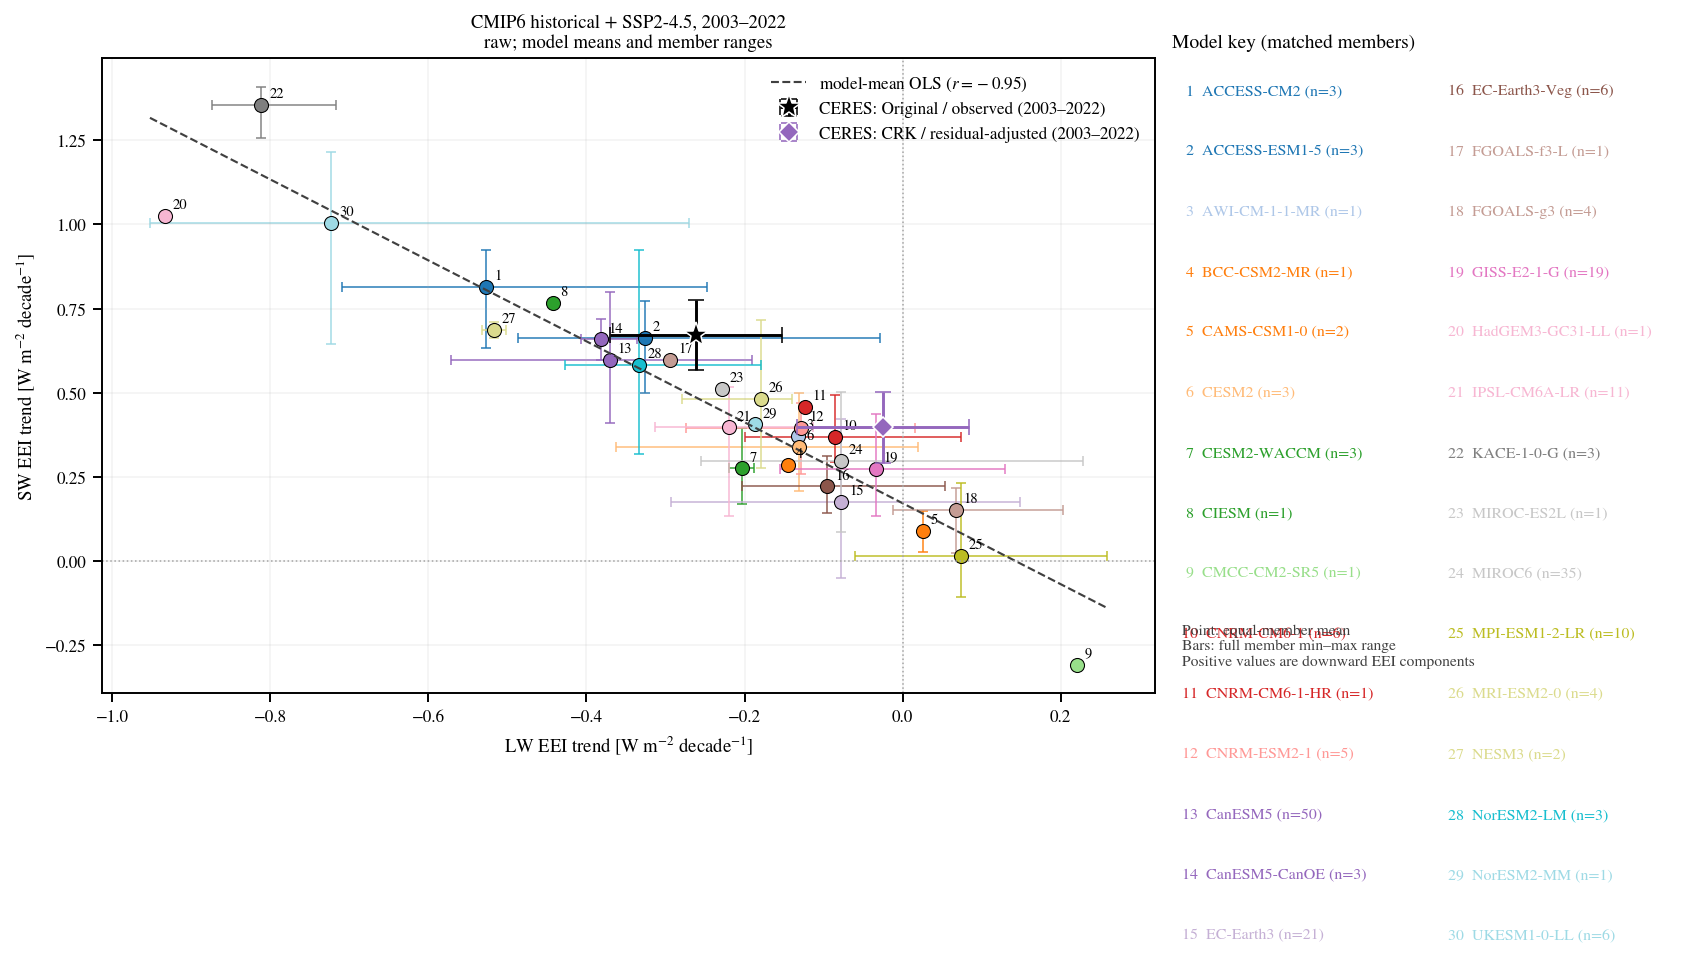

In [31]:
plot_table = model_trend_summary.reset_index()
colors = plt.cm.tab20(np.linspace(0, 1, len(plot_table)))
fig = plt.figure(figsize=(12, 6.6), dpi=140, constrained_layout=True)
grid = fig.add_gridspec(1, 2, width_ratios=(3.2, 1.55))
ax = fig.add_subplot(grid[0, 0])
key_ax = fig.add_subplot(grid[0, 1])

for color, row in zip(colors, plot_table.itertuples(index=False)):
    xerr = np.array([[row.LW_mean - row.LW_min], [row.LW_max - row.LW_mean]])
    yerr = np.array([[row.SW_mean - row.SW_min], [row.SW_max - row.SW_mean]])
    ax.errorbar(
        row.LW_mean, row.SW_mean, xerr=xerr, yerr=yerr, fmt="none",
        ecolor=color, elinewidth=1.0, capsize=2.5, alpha=0.75, zorder=1,
    )
    ax.scatter(row.LW_mean, row.SW_mean, s=52, color=color, edgecolor="black",
               linewidth=0.55, zorder=2)
    ax.annotate(str(row.plot_number), (row.LW_mean, row.SW_mean),
                xytext=(4, 4), textcoords="offset points", fontsize=7.5)

regression_slope, regression_intercept = np.polyfit(
    plot_table["LW_mean"], plot_table["SW_mean"], 1
)
x_line = np.linspace(plot_table["LW_min"].min(), plot_table["LW_max"].max(), 200)
ax.plot(x_line, regression_intercept + regression_slope * x_line,
        color="0.25", lw=1.1, ls="--",
        label=rf"model-mean OLS ($r={model_mean_correlation:.2f}$)")
ax.axhline(0, color="0.65", lw=0.8, ls=":")
ax.axvline(0, color="0.65", lw=0.8, ls=":")
ax.set(
    xlabel=r"LW EEI trend [W m$^{-2}$ decade$^{-1}$]",
    ylabel=r"SW EEI trend [W m$^{-2}$ decade$^{-1}$]",
    title=(f"CMIP6 historical + SSP2-4.5, {TREND_START_YEAR}–{TREND_END_YEAR}\n"
           f"{TREND_DATA_PRODUCT}; model means and member ranges"),
)
ax.grid(alpha=0.16)

# Add CERES estimates to the SW-versus-LW trend plot.
# x = LW trend; y = SW trend. The supplied errors are assumed to be ±2σ.
ceres_styles = {
    "Original / observed": {
        "marker": "*",
        "color": "black",
        "markersize": 13,
    },
    "CRK / residual-adjusted": {
        "marker": "D",
        "color": "tab:purple",
        "markersize": 7,
    },
}

for method, style in ceres_styles.items():
    method_data = ceresdf.loc[ceresdf["method"] == method].set_index("component")

    lw = method_data.loc["LW"]
    sw = method_data.loc["SW"]

    ax.errorbar(
        x=lw["trend_W_m2_decade"],
        y=sw["trend_W_m2_decade"],
        xerr=lw["error_W_m2_decade"],
        yerr=sw["error_W_m2_decade"],
        fmt=style["marker"],
        color=style["color"],
        markeredgecolor="white",
        markeredgewidth=0.8,
        markersize=style["markersize"],
        elinewidth=1.5,
        capsize=4,
        zorder=10,
        label=f'CERES: {method} ({lw["period"]})',
    )

ax.legend(frameon=False, loc="upper right", fontsize=8)


ax.legend(frameon=False, loc="upper right")

key_ax.axis("off")
key_ax.set_title("Model key (matched members)", loc="left", fontsize=10)
split = int(np.ceil(len(plot_table) / 2))
for position, row in enumerate(plot_table.itertuples(index=False)):
    column = position // split
    row_in_column = position % split
    x_position = 0.02 + 0.52 * column
    y_position = 0.96 - 0.095 * row_in_column
    key_ax.text(
        x_position, y_position,
        f"{row.plot_number:>2}  {row.source_id} (n={row.n_members})",
        color=colors[position], fontsize=8.2, transform=key_ax.transAxes, va="top",
    )
key_ax.text(
    0.02, 0.04,
    "Point: equal-member mean\nBars: full member min–max range\n"
    "Positive values are downward EEI components",
    fontsize=8, color="0.25", transform=key_ax.transAxes, va="bottom",
)
plt.show()

,Myhre_figure_number,source_id,Myhre_n_members,ECS_Table_S1_K,ECS_used_K
0,1,ACCESS-CM2,10,4.73,4.73
1,2,ACCESS-ESM1-5,40,3.86,3.86
2,3,AWI-CM-1-1-MR,1,3.13,3.13
3,4,BCC-CSM2-MR,1,3.03,3.03
4,5,CAMS-CSM1-0,2,2.32,2.32
5,6,CanESM5,50,5.62,5.62
6,7,CESM2,3,5.24,3.37
7,8,CESM2-WACCM,3,4.75,4.75
8,9,CIESM,1,5.54,5.54
9,10,CNRM-CM6-1,6,4.96,4.96


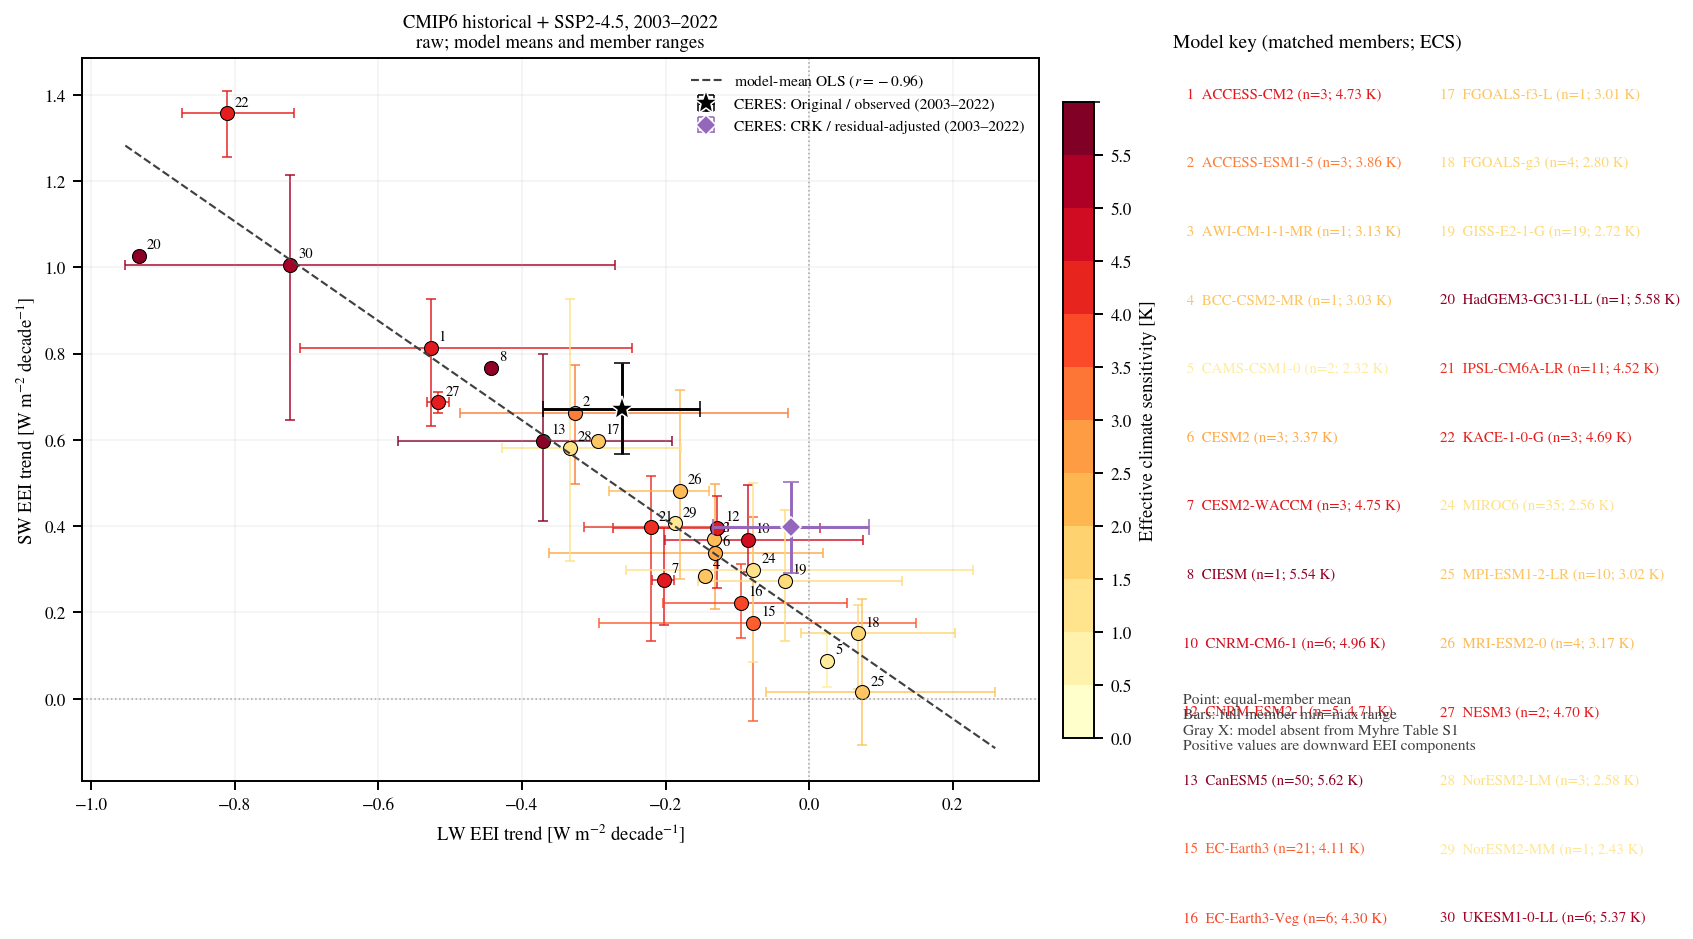

In [32]:
from matplotlib.colors import Normalize

# ---------------------------------------------------------------------
# Digitize Myhre et al. (2025), Table S1.
# "ECS_Table_S1_K" is the value printed in the supplement.
# "ECS_used_K" applies the requested CESM2 correction.
# ---------------------------------------------------------------------
ecs_table_s1 = pd.DataFrame(
    [
        (1,  "ACCESS-CM2",        10, 4.73),
        (2,  "ACCESS-ESM1-5",     40, 3.86),
        (3,  "AWI-CM-1-1-MR",      1, 3.13),
        (4,  "BCC-CSM2-MR",         1, 3.03),
        (5,  "CAMS-CSM1-0",         2, 2.32),
        (6,  "CanESM5",             50, 5.62),
        (7,  "CESM2",                 3, 5.24),
        (8,  "CESM2-WACCM",           3, 4.75),
        (9,  "CIESM",                  1, 5.54),
        (10, "CNRM-CM6-1",             6, 4.96),
        (11, "CNRM-ESM2-1",            5, 4.71),
        (12, "EC-Earth3",               4, 4.11),
        (13, "EC-Earth3-Veg",           8, 4.30),
        (14, "E3SM-1-0",                5, 5.34),
        (15, "FGOALS-f3-L",             1, 3.01),
        (16, "FGOALS-g3",               4, 2.80),
        (17, "FIO-ESM-2-0",             3, 4.26),
        (18, "GFDL-CM4",                1, 3.94),
        (19, "GFDL-ESM4",               1, 2.67),
        (20, "GISS-E2-1-G",            10, 2.72),
        (21, "GISS-E2-1-H",            10, 3.08),
        (22, "GISS-E2-2-G",             5, 2.39),
        (23, "HadGEM3-GC31-LL",         4, 5.58),
        (24, "IITM-ESM",                1, 2.37),
        (25, "INM-CM4-8",               1, 1.85),
        (26, "INM-CM5-0",               1, 1.90),
        (27, "IPSL-CM6A-LR",            7, 4.52),
        (28, "KACE-1-0-G",              3, 4.69),
        (29, "MIROC6",                 50, 2.56),
        (30, "MPI-ESM1-2-HR",           2, 2.96),
        (31, "MPI-ESM1-2-LR",          30, 3.02),
        (32, "MRI-ESM2-0",              6, 3.17),
        (33, "NESM3",                   2, 4.70),
        (34, "NorESM2-LM",              1, 2.58),
        (35, "NorESM2-MM",              1, 2.43),
        (36, "TaiESM1",                 1, 4.35),
        (37, "UKESM1-0-LL",             5, 5.37),
    ],
    columns=[
        "Myhre_figure_number",
        "source_id",
        "Myhre_n_members",
        "ECS_Table_S1_K",
    ],
)

ecs_table_s1["ECS_used_K"] = ecs_table_s1["ECS_Table_S1_K"]

# Requested correction: use the 2xCO2 CESM2 estimate.
ecs_table_s1.loc[
    ecs_table_s1["source_id"].eq("CESM2"), "ECS_used_K"
] = 3.37

display(ecs_table_s1)


# ---------------------------------------------------------------------
# Attach ECS to the models available in the present analysis.
# ---------------------------------------------------------------------
plot_table = (
    model_trend_summary
    .reset_index()
    .merge(
        ecs_table_s1[
            ["source_id", "Myhre_figure_number", "ECS_Table_S1_K", "ECS_used_K"]
        ],
        on="source_id",
        how="inner",  # retains only models present in Table S1
        validate="one_to_one",
    )
    .copy()
)
missing_ecs = []  # This older draft is retained only for comparison.
# missing_ecs = plot_table.loc[
#     plot_table["ECS_used_K"].isna(), "source_id"
# ].tolist()

if missing_ecs:
    print(
        "Models not present in Myhre Table S1; plotted in gray:",
        ", ".join(missing_ecs),
    )

model_mean_correlation = plot_table[["LW_mean", "SW_mean"]].corr().iloc[0, 1]


# ---------------------------------------------------------------------
# Myhre-style ECS colors.
# ---------------------------------------------------------------------
cmap = plt.cm.YlOrRd
ecs_norm = Normalize(vmin=1.8, vmax=5.7)
missing_ecs_color = "0.65"

plot_colors = [
    cmap(ecs_norm(ecs)) if pd.notna(ecs) else missing_ecs_color
    for ecs in plot_table["ECS_used_K"]
]


# ---------------------------------------------------------------------
# Plot.
# ---------------------------------------------------------------------
fig = plt.figure(figsize=(12, 6.6), dpi=140, constrained_layout=True)
grid = fig.add_gridspec(1, 2, width_ratios=(3.2, 1.65))
ax = fig.add_subplot(grid[0, 0])
key_ax = fig.add_subplot(grid[0, 1])

for color, row in zip(plot_colors, plot_table.itertuples(index=False)):
    xerr = np.array([
        [row.LW_mean - row.LW_min],
        [row.LW_max - row.LW_mean],
    ])
    yerr = np.array([
        [row.SW_mean - row.SW_min],
        [row.SW_max - row.SW_mean],
    ])

    marker = "o" if pd.notna(row.ECS_used_K) else "X"

    ax.errorbar(
        row.LW_mean,
        row.SW_mean,
        xerr=xerr,
        yerr=yerr,
        fmt="none",
        ecolor=color,
        elinewidth=1.0,
        capsize=2.5,
        alpha=0.75,
        zorder=1,
    )
    ax.scatter(
        row.LW_mean,
        row.SW_mean,
        s=52,
        marker=marker,
        color=color,
        edgecolor="black",
        linewidth=0.55,
        zorder=2,
    )
    ax.annotate(
        str(row.plot_number),
        (row.LW_mean, row.SW_mean),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=7.5,
    )


# Intermodel regression.
regression_slope, regression_intercept = np.polyfit(
    plot_table["LW_mean"],
    plot_table["SW_mean"],
    1,
)
x_line = np.linspace(
    plot_table["LW_min"].min(),
    plot_table["LW_max"].max(),
    200,
)

ax.plot(
    x_line,
    regression_intercept + regression_slope * x_line,
    color="0.25",
    lw=1.1,
    ls="--",
    label=rf"model-mean OLS ($r={model_mean_correlation:.2f}$)",
)

ax.axhline(0, color="0.65", lw=0.8, ls=":")
ax.axvline(0, color="0.65", lw=0.8, ls=":")
ax.set(
    xlabel=r"LW EEI trend [W m$^{-2}$ decade$^{-1}$]",
    ylabel=r"SW EEI trend [W m$^{-2}$ decade$^{-1}$]",
    title=(
        f"CMIP6 historical + SSP2-4.5, "
        f"{TREND_START_YEAR}–{TREND_END_YEAR}\n"
        f"{TREND_DATA_PRODUCT}; model means and member ranges"
    ),
)
ax.grid(alpha=0.16)

# ECS color bar.
from matplotlib.colors import BoundaryNorm

ecs_bounds = np.arange(0.00, 6.25, 0.5)
ecs_ticks = np.arange(0.0, 6.0, 0.5)

cmap = plt.cm.YlOrRd
ecs_norm = BoundaryNorm(ecs_bounds, cmap.N, clip=True)

colorbar_mappable = plt.cm.ScalarMappable(norm=ecs_norm, cmap=cmap)
colorbar_mappable.set_array([])

colorbar = fig.colorbar(
    colorbar_mappable,
    ax=ax,
    boundaries=ecs_bounds,
    ticks=ecs_ticks,
    spacing="uniform",
    pad=0.025,
    shrink=0.88,
)
colorbar.set_label("Effective climate sensitivity [K]")


# colorbar_mappable = plt.cm.ScalarMappable(norm=ecs_norm, cmap=cmap)
# colorbar_mappable.set_array([])
# colorbar = fig.colorbar(
#     colorbar_mappable,
#     ax=ax,
#     pad=0.025,
#     shrink=0.88,
# )
# colorbar.set_label("Effective climate sensitivity [K]")


# ---------------------------------------------------------------------
# Add the two CERES estimates.
# error_W_m2_decade is assumed to contain the full ±2σ uncertainty.
# ---------------------------------------------------------------------
ceres_styles = {
    "Original / observed": {
        "marker": "*",
        "color": "black",
        "markersize": 13,
    },
    "CRK / residual-adjusted": {
        "marker": "D",
        "color": "tab:purple",
        "markersize": 7,
    },
}

for method, style in ceres_styles.items():
    method_data = (
        ceresdf.loc[ceresdf["method"].eq(method)]
        .set_index("component")
    )

    lw = method_data.loc["LW"]
    sw = method_data.loc["SW"]

    ax.errorbar(
        x=lw["trend_W_m2_decade"],
        y=sw["trend_W_m2_decade"],
        xerr=lw["error_W_m2_decade"],
        yerr=sw["error_W_m2_decade"],
        fmt=style["marker"],
        color=style["color"],
        markeredgecolor="white",
        markeredgewidth=0.8,
        markersize=style["markersize"],
        elinewidth=1.5,
        capsize=4,
        zorder=10,
        label=f'CERES: {method} ({lw["period"]})',
    )

ax.legend(frameon=False, loc="upper right", fontsize=8)


# ---------------------------------------------------------------------
# Model key.
# ---------------------------------------------------------------------
key_ax.axis("off")
key_ax.set_title(
    "Model key (matched members; ECS)",
    loc="left",
    fontsize=10,
)

split = int(np.ceil(len(plot_table) / 2))

for position, row in enumerate(plot_table.itertuples(index=False)):
    column = position // split
    row_in_column = position % split
    x_position = 0.02 + 0.52 * column
    y_position = 0.96 - 0.095 * row_in_column

    ecs_label = (
        f"{row.ECS_used_K:.2f} K"
        if pd.notna(row.ECS_used_K)
        else "ECS n/a"
    )

    key_ax.text(
        x_position,
        y_position,
        (
            f"{row.plot_number:>2}  {row.source_id} "
            f"(n={row.n_members}; {ecs_label})"
        ),
        color=plot_colors[position],
        fontsize=7.7,
        transform=key_ax.transAxes,
        va="top",
    )

key_ax.text(
    0.02,
    0.04,
    "Point: equal-member mean\n"
    "Bars: full member min–max range\n"
    "Gray X: model absent from Myhre Table S1\n"
    "Positive values are downward EEI components",
    fontsize=8,
    color="0.25",
    transform=key_ax.transAxes,
    va="bottom",
)

plt.show()

,Myhre_figure_number,source_id,Myhre_n_members,ECS_Table_S1_K,ECS_used_K
0,1,ACCESS-CM2,10,4.73,4.73
1,2,ACCESS-ESM1-5,40,3.86,3.86
2,3,AWI-CM-1-1-MR,1,3.13,3.13
3,4,BCC-CSM2-MR,1,3.03,3.03
4,5,CAMS-CSM1-0,2,2.32,2.32
5,6,CanESM5,50,5.62,5.62
6,7,CESM2,3,5.24,3.37
7,8,CESM2-WACCM,3,4.75,4.75
8,9,CIESM,1,5.54,5.54
9,10,CNRM-CM6-1,6,4.96,4.96


Models plotted after Table S1 matching and exclusions: 25


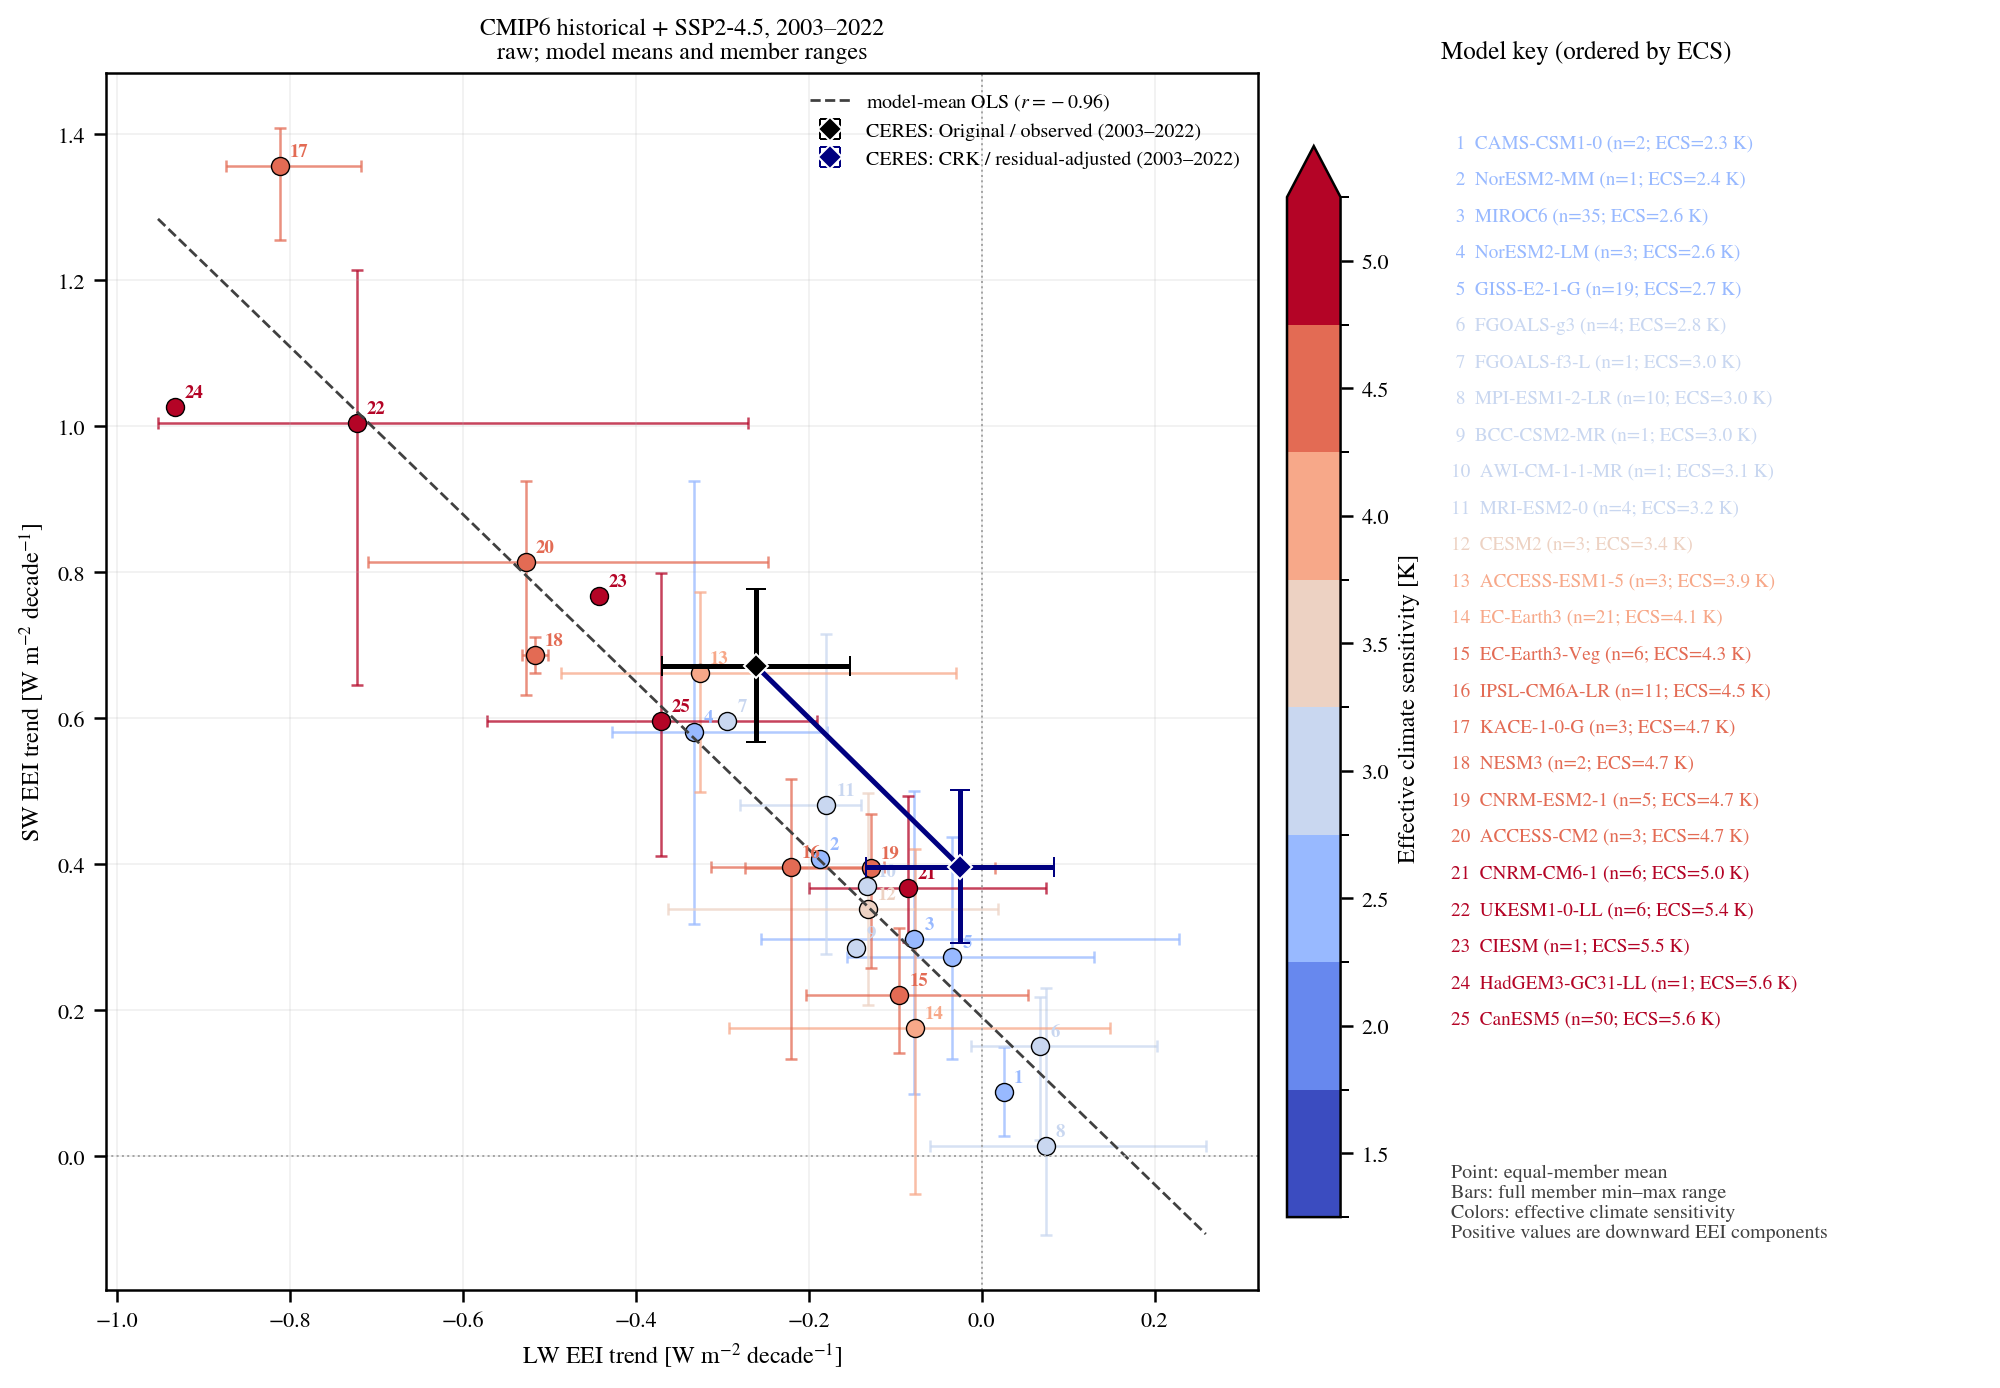

In [33]:
from matplotlib.colors import BoundaryNorm

# ---------------------------------------------------------------------
# Myhre et al. (2025), Table S1.
# ECS_used_K applies the requested CESM2 correction.
# ---------------------------------------------------------------------
ecs_table_s1 = pd.DataFrame(
    [
        (1,  "ACCESS-CM2",        10, 4.73),
        (2,  "ACCESS-ESM1-5",     40, 3.86),
        (3,  "AWI-CM-1-1-MR",      1, 3.13),
        (4,  "BCC-CSM2-MR",         1, 3.03),
        (5,  "CAMS-CSM1-0",         2, 2.32),
        (6,  "CanESM5",             50, 5.62),
        (7,  "CESM2",                3, 5.24),
        (8,  "CESM2-WACCM",          3, 4.75),
        (9,  "CIESM",                 1, 5.54),
        (10, "CNRM-CM6-1",            6, 4.96),
        (11, "CNRM-ESM2-1",           5, 4.71),
        (12, "EC-Earth3",              4, 4.11),
        (13, "EC-Earth3-Veg",          8, 4.30),
        (14, "E3SM-1-0",               5, 5.34),
        (15, "FGOALS-f3-L",            1, 3.01),
        (16, "FGOALS-g3",              4, 2.80),
        (17, "FIO-ESM-2-0",            3, 4.26),
        (18, "GFDL-CM4",               1, 3.94),
        (19, "GFDL-ESM4",              1, 2.67),
        (20, "GISS-E2-1-G",           10, 2.72),
        (21, "GISS-E2-1-H",           10, 3.08),
        (22, "GISS-E2-2-G",            5, 2.39),
        (23, "HadGEM3-GC31-LL",        4, 5.58),
        (24, "IITM-ESM",               1, 2.37),
        (25, "INM-CM4-8",              1, 1.85),
        (26, "INM-CM5-0",              1, 1.90),
        (27, "IPSL-CM6A-LR",           7, 4.52),
        (28, "KACE-1-0-G",             3, 4.69),
        (29, "MIROC6",                50, 2.56),
        (30, "MPI-ESM1-2-HR",          2, 2.96),
        (31, "MPI-ESM1-2-LR",         30, 3.02),
        (32, "MRI-ESM2-0",             6, 3.17),
        (33, "NESM3",                  2, 4.70),
        (34, "NorESM2-LM",             1, 2.58),
        (35, "NorESM2-MM",             1, 2.43),
        (36, "TaiESM1",                1, 4.35),
        (37, "UKESM1-0-LL",            5, 5.37),
    ],
    columns=[
        "Myhre_figure_number",
        "source_id",
        "Myhre_n_members",
        "ECS_Table_S1_K",
    ],
)

ecs_table_s1["ECS_used_K"] = ecs_table_s1["ECS_Table_S1_K"]

# Requested correction: CESM2 estimate for 2xCO2.
ecs_table_s1.loc[
    ecs_table_s1["source_id"].eq("CESM2"),
    "ECS_used_K",
] = 3.37

display(ecs_table_s1)


# ---------------------------------------------------------------------
# Retain only models present in both this analysis and Myhre Table S1.
# ---------------------------------------------------------------------
plot_table = (
    model_trend_summary
    .reset_index()
    .merge(
        ecs_table_s1[
            [
                "source_id",
                "Myhre_figure_number",
                "ECS_Table_S1_K",
                "ECS_used_K",
            ]
        ],
        on="source_id",
        how="inner",
        validate="one_to_one",
    )
    .copy()
)

# Exclude CESM2-WACCM, then order and renumber models by corrected ECS.
plot_table = (
    plot_table.loc[~plot_table["source_id"].eq("CESM2-WACCM")]
    .sort_values(["ECS_used_K", "source_id"], ascending=[True, True])
    .reset_index(drop=True)
)
plot_table["plot_number"] = np.arange(1, len(plot_table) + 1)

assert plot_table["ECS_used_K"].notna().all()
assert "CESM2-WACCM" not in set(plot_table["source_id"])
print(f"Models plotted after Table S1 matching and exclusions: {len(plot_table)}")

model_mean_correlation = (
    plot_table[["LW_mean", "SW_mean"]]
    .corr()
    .iloc[0, 1]
)


# ---------------------------------------------------------------------
# Discrete ECS colors at 0.5 K intervals.
#
# Bounds are centered around colorbar ticks:
# 1.75–2.25 -> 2.0 K color
# 2.25–2.75 -> 2.5 K color, etc.
# ---------------------------------------------------------------------
# cmap = plt.cm.YlOrRd
cmap = plt.cm.coolwarm
ecs_bounds = np.arange(1.25, 5.25 + 0.001, 0.5)
ecs_ticks = np.arange(1.5, 5.0 + 0.001, 0.5)
ecs_norm = BoundaryNorm(ecs_bounds, cmap.N, clip=True)

# These exact colors are reused for the points, error bars,
# plot annotations, and model-key text.
plot_colors = [
    cmap(ecs_norm(ecs))
    for ecs in plot_table["ECS_used_K"]
]


# ---------------------------------------------------------------------
# Plot.
# ---------------------------------------------------------------------
fig = plt.figure(
    figsize=(11, 7.6),
    dpi=180,
    constrained_layout=True,
)
grid = fig.add_gridspec(
    1,
    2,
    width_ratios=(3.4, 1.6),
)
ax = fig.add_subplot(grid[0, 0])
key_ax = fig.add_subplot(grid[0, 1])

for color, row in zip(
    plot_colors,
    plot_table.itertuples(index=False),
):
    xerr = np.array(
        [
            [row.LW_mean - row.LW_min],
            [row.LW_max - row.LW_mean],
        ]
    )
    yerr = np.array(
        [
            [row.SW_mean - row.SW_min],
            [row.SW_max - row.SW_mean],
        ]
    )

    ax.errorbar(
        row.LW_mean,
        row.SW_mean,
        xerr=xerr,
        yerr=yerr,
        fmt="none",
        ecolor=color,
        elinewidth=1.0,
        capsize=2.5,
        alpha=0.75,
        zorder=1,
    )

    ax.scatter(
        row.LW_mean,
        row.SW_mean,
        s=52,
        marker="o",
        color=color,
        edgecolor="black",
        linewidth=0.55,
        zorder=2,
    )

    # The numeric annotation uses the same ECS color.
    ax.annotate(
        str(row.plot_number),
        (row.LW_mean, row.SW_mean),
        xytext=(4, 4),
        textcoords="offset points",
        color=color,
        fontsize=7.5,
        fontweight="bold",
        zorder=3,
    )


# ---------------------------------------------------------------------
# Intermodel regression.
# ---------------------------------------------------------------------
regression_slope, regression_intercept = np.polyfit(
    plot_table["LW_mean"],
    plot_table["SW_mean"],
    1,
)

x_line = np.linspace(
    plot_table["LW_min"].min(),
    plot_table["LW_max"].max(),
    200,
)

ax.plot(
    x_line,
    regression_intercept + regression_slope * x_line,
    color="0.25",
    lw=1.1,
    ls="--",
    label=rf"model-mean OLS ($r={model_mean_correlation:.2f}$)",
)

ax.axhline(0, color="0.65", lw=0.8, ls=":")
ax.axvline(0, color="0.65", lw=0.8, ls=":")

ax.set(
    xlabel=r"LW EEI trend [W m$^{-2}$ decade$^{-1}$]",
    ylabel=r"SW EEI trend [W m$^{-2}$ decade$^{-1}$]",
    title=(
        f"CMIP6 historical + SSP2-4.5, "
        f"{TREND_START_YEAR}–{TREND_END_YEAR}\n"
        f"{TREND_DATA_PRODUCT}; model means and member ranges"
    ),
)

ax.grid(alpha=0.16)


# ---------------------------------------------------------------------
# ECS colorbar using the same cmap and norm as the model colors.
# ---------------------------------------------------------------------
colorbar_mappable = plt.cm.ScalarMappable(
    norm=ecs_norm,
    cmap=cmap,
)
colorbar_mappable.set_array([])

colorbar = fig.colorbar(
    colorbar_mappable,
    ax=ax,
    boundaries=ecs_bounds,
    ticks=ecs_ticks,
    spacing="uniform",
    pad=0.025,
    shrink=0.88,
    extend='max',
)

colorbar.set_label("Effective climate sensitivity [K]")


# ---------------------------------------------------------------------
# CERES estimates.
#
# error_W_m2_decade is assumed to contain the full ±2σ uncertainty.
# ---------------------------------------------------------------------
ceres_styles = {
    "Original / observed": {
        "marker": "D",
        "color": "black",
        "markersize": 7,
    },
    "CRK / residual-adjusted": {
        "marker": "D",
        "color": "navy",
        "markersize": 7,
    },
}

for method, style in ceres_styles.items():
    method_data = (
        ceresdf.loc[ceresdf["method"].eq(method)]
        .set_index("component")
    )

    lw = method_data.loc["LW"]
    sw = method_data.loc["SW"]

    ax.errorbar(
        x=lw["trend_W_m2_decade"],
        y=sw["trend_W_m2_decade"],
        xerr=lw["error_W_m2_decade"],
        yerr=sw["error_W_m2_decade"],
        fmt=style["marker"],
        color=style["color"],
        markeredgecolor="white",
        markeredgewidth=0.8,
        markersize=style["markersize"],
        elinewidth=2,
        capsize=4,
        zorder=10,
        label=f'CERES: {method} ({lw["period"]})',
    )
    
ax.plot(
    ceresdf.query("component == 'LW'").set_index("method").loc[list(ceres_styles), "trend_W_m2_decade"],
    ceresdf.query("component == 'SW'").set_index("method").loc[list(ceres_styles), "trend_W_m2_decade"],
    color="navy", linewidth=2, zorder=9,
)

ax.legend(
    frameon=False,
    loc="upper right",
    fontsize=8,
    ncol=1,
)


# ---------------------------------------------------------------------
# Model key. Text uses the exact same colors as the plotted models.
# ---------------------------------------------------------------------
key_ax.axis("off")
key_ax.set_title(
    "Model key (ordered by ECS)",
    loc="left",
    fontsize=10,
)

key_y_positions = np.linspace(0.95, 0.23, len(plot_table))

for position, (color, row) in enumerate(
    zip(
        plot_colors,
        plot_table.itertuples(index=False),
    )
):
    x_position = 0.02
    y_position = key_y_positions[position]

    key_ax.text(
        x_position,
        y_position,
        (
            f"{row.plot_number:>2}  {row.source_id} "
            f"(n={row.n_members}; ECS={row.ECS_used_K:.1f} K)"
        ),
        color="black",
        fontsize=7.7,
        transform=key_ax.transAxes,
        va="top",
    )

key_ax.text(
    0.02,
    0.04,
    "Point: equal-member mean\n"
    "Bars: full member min–max range\n"
    "Colors: effective climate sensitivity\n"
    "Positive values are downward EEI components",
    fontsize=8,
    color="0.25",
    transform=key_ax.transAxes,
    va="bottom",
)

plt.show()

## Abrupt-4xCO2 SST warming patterns: experiment years 1–150

This section builds one forced SST response pattern per model from CMIP6 `abrupt-4xCO2` output found in either the shared NCAR CMIP Analysis Platform or the user's `esgfdownload` staging area. Monthly `Amon/tas` and `Omon/tos` are first converted to annual means with `groupby("time.year")`, then coarsened to configurable multi-year means. Complete `tas` and `tos` members are averaged independently within each model, so their variant labels do not have to match. The binned `tos` fields are regridded before the spatial regressions.

By default, each map is the OLS slope of local SST against that model's global-mean near-surface air temperature, in K SST per K global warming. Set `PATTERN_PREDICTOR = "experiment_year"` for an ordinary SST time trend in K per decade. The multimodel mean can be equal-model weighted or use the subset-specific code-ancestry weights of [Kuma et al. (2023)](https://doi.org/10.1029/2022MS003588).

Set `DEDRIFT_ABRUPT = True` to remove a member-specific linear `piControl` drift. The code requires `parent_variant_label`, `branch_time_in_parent`, and `parent_time_units` from each abrupt file, converts the branch time with the control calendar, and fits only the 150 control years beginning at that branch. It never silently substitutes the first 150 years of a control. Drift is removed on each native grid before global averaging or regridding.

This section requires the `kant` environment (`xesmf`, `dask`, and `cartopy`). The 96×144 destination uses the exact cell centers in `domain.lnd.fv1.9x2.5_gx1v6.090206.nc`. Its land fraction defines land at ≥50%; only cells below 50% land are valid `tos` destinations. For speed, only the naturally first complete member per variable/model is loaded. AWI-CM-1-1-MR and INM-CM4-8 are excluded; among CESM2-family source IDs, only CESM2 `r1i1p1f1` is retained.

In [22]:
import os
import re

import cftime

import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point
import xesmf as xe

CMIP6_SHARED_ROOT = Path("/lustre/desc1/mirrors/cmip.mirror/CMIP6/CMIP")
CMIP6_DOWNLOAD_ROOT = (
    Path("/glade/campaign/collections/cmip.mirror/.tmp")
    / os.environ.get("USER", "vcooper")
    / "CMIP6/CMIP"
)
# Search both the shared CMIP Analysis Platform and NCAR esgfdownload's
# per-user staging area. Add another CMIP6/CMIP root here if needed.
CMIP6_DATA_ROOTS = [CMIP6_SHARED_ROOT, CMIP6_DOWNLOAD_ROOT]
CMIP6_DATA_ROOTS = list(dict.fromkeys(
    path.resolve() for path in CMIP6_DATA_ROOTS if path.is_dir()
))
ABRUPT_ROOT = CMIP6_SHARED_ROOT  # retained for older helper cells
ABRUPT_N_YEARS = 150

# False: use raw abrupt-4xCO2 output. True: subtract the linear drift fitted
# to the branch-aligned piControl segment for every tas/tos member.
DEDRIFT_ABRUPT = True
PICONTROL_ROOTS = CMIP6_DATA_ROOTS

# Monthly -> annual means -> this many years per regression point.
# Use 1, 5, 10, etc.; incomplete final blocks are dropped.
TEMPORAL_BIN_YEARS = 5

# Load only the naturally first complete member for each variable/model.
# This normally selects r1 and avoids processing large multi-member ensembles.
MAX_MEMBERS_PER_VARIABLE = 1
ABRUPT_EXCLUDED_MODELS = {"AWI-CM-1-1-MR", "INM-CM4-8"}
# Among source_ids beginning with CESM2, retain only CESM2 itself.
CESM2_ONLY_SOURCE_ID = "CESM2"
# Strict per-model override, applied to both tas and tos.
ABRUPT_MEMBER_OVERRIDES = {"CESM2": "r1i1p1f1"}

# "global_tas": local tos regressed on global-mean tas [K K-1].
# "experiment_year": local tos regressed on time [K decade-1].
PATTERN_PREDICTOR = "global_tas"

# "equal" or "ancestry". Weighting is applied across model-level patterns,
# after available members have been averaged within each model.
MULTIMODEL_WEIGHTING = "equal"

# Continue past a model-specific read/regridding failure and report it.
# Set False while debugging if you prefer the first failure to stop the cell.
CONTINUE_ON_MODEL_ERROR = True

# Exact fv1.9x2.5 centers and land fraction from the CESM domain file.
# Destination cells with land fraction >= 0.50 are masked from tos.
TARGET_DOMAIN_FILE = Path(
    "/glade/u/home/vcooper/work/hist_sst/data/ref/"
    "domain.lnd.fv1.9x2.5_gx1v6.090206.nc"
)
TARGET_LAND_FRACTION_THRESHOLD = 0.50
with xr.open_dataset(TARGET_DOMAIN_FILE, engine="netcdf4") as target_domain:
    domain_lon = target_domain["xc"].to_numpy()
    domain_lat = target_domain["yc"].to_numpy()
    domain_land_fraction = target_domain["frac"].to_numpy()
if not (
    np.allclose(domain_lon, domain_lon[[0], :])
    and np.allclose(domain_lat, domain_lat[:, [0]])
):
    raise ValueError(f"Expected a rectilinear destination grid in {TARGET_DOMAIN_FILE}")
TARGET_LAT = domain_lat[:, 0]
TARGET_LON = domain_lon[0, :]
TARGET_NLAT, TARGET_NLON = domain_land_fraction.shape
ABRUPT_TARGET_LAND_FRACTION = xr.DataArray(
    domain_land_fraction,
    dims=("lat", "lon"),
    coords={"lat": TARGET_LAT, "lon": TARGET_LON},
    name="destination_land_fraction",
    attrs={
        "long_name": "destination grid-cell land fraction",
        "source": str(TARGET_DOMAIN_FILE),
    },
)
ABRUPT_TARGET_OCEAN_MASK = (
    ABRUPT_TARGET_LAND_FRACTION < TARGET_LAND_FRACTION_THRESHOLD
).astype("int32").rename("mask")
ABRUPT_TARGET_OCEAN_MASK.attrs.update({
    "long_name": "xESMF destination mask (1=ocean-valid, 0=land-masked)",
    "land_fraction_threshold": TARGET_LAND_FRACTION_THRESHOLD,
})
ABRUPT_TARGET_GRID = xr.Dataset({"mask": ABRUPT_TARGET_OCEAN_MASK})
ABRUPT_TARGET_GRID["lat"].attrs["units"] = "degrees_north"
ABRUPT_TARGET_GRID["lon"].attrs["units"] = "degrees_east"
ABRUPT_REGRIDDED_OUTPUT_DIRECTORY = Path(
    "/glade/derecho/scratch/vcooper/projects/bayecs/processed"
)

KUMA_GENEALOGY_COMMIT = "9ac457e0998326696025910062c2255ea5e885a5"
KUMA_MODELS_CANDIDATES = [
    Path("reference/kuma_models_9ac457e.csv"),
    Path("bayecs/reference/kuma_models_9ac457e.csv"),
    Path(
        "/glade/derecho/scratch/vcooper/projects/bayecs/"
        "reference/kuma_models_9ac457e.csv"
    ),
]

if not CMIP6_DATA_ROOTS:
    raise FileNotFoundError("No configured CMIP6 data root exists")
if ABRUPT_N_YEARS < 2:
    raise ValueError("ABRUPT_N_YEARS must be at least 2")
if not 1 <= TEMPORAL_BIN_YEARS <= ABRUPT_N_YEARS:
    raise ValueError("TEMPORAL_BIN_YEARS must be between 1 and ABRUPT_N_YEARS")
if PATTERN_PREDICTOR not in {"global_tas", "experiment_year"}:
    raise ValueError(PATTERN_PREDICTOR)
if MULTIMODEL_WEIGHTING not in {"equal", "ancestry"}:
    raise ValueError(MULTIMODEL_WEIGHTING)
if DEDRIFT_ABRUPT and not PICONTROL_ROOTS:
    raise FileNotFoundError("No piControl search root exists")

print(
    f"Abrupt-4xCO2 years: 1-{ABRUPT_N_YEARS}; "
    f"temporal means: {TEMPORAL_BIN_YEARS} year(s); "
    f"target: {TARGET_NLAT}x{TARGET_NLON} fv1.9x2.5; "
    f"predictor: {PATTERN_PREDICTOR!r}; "
    f"MMM weighting: {MULTIMODEL_WEIGHTING!r}; "
    f"piControl de-drifting: {DEDRIFT_ABRUPT}"
)
print("CMIP6 search roots:")
for root in CMIP6_DATA_ROOTS:
    print(f"  {root}")
print(
    f"Destination ocean-valid cells: {int(ABRUPT_TARGET_OCEAN_MASK.sum())}/"
    f"{ABRUPT_TARGET_OCEAN_MASK.size}; land fraction threshold: "
    f"{TARGET_LAND_FRACTION_THRESHOLD:.0%}"
)
print(
    f"Member cap per model/variable: {MAX_MEMBERS_PER_VARIABLE}; "
    f"excluded models: {sorted(ABRUPT_EXCLUDED_MODELS)}; "
    f"CESM2-family selection: {CESM2_ONLY_SOURCE_ID} "
    f"{ABRUPT_MEMBER_OVERRIDES[CESM2_ONLY_SOURCE_ID]}"
)

Abrupt-4xCO2 years: 1-150; temporal means: 5 year(s); target: 96x144 fv1.9x2.5; predictor: 'global_tas'; MMM weighting: 'equal'; piControl de-drifting: True
CMIP6 search roots:
  /lustre/desc1/mirrors/cmip.mirror/CMIP6/CMIP
  /lustre/desc1/mirrors/cmip.mirror/.tmp/vcooper/CMIP6/CMIP
Destination ocean-valid cells: 9085/13824; land fraction threshold: 50%
Member cap per model/variable: 1; excluded models: ['AWI-CM-1-1-MR', 'INM-CM4-8']; CESM2-family selection: CESM2 r1i1p1f1


In [23]:
_ABRUPT_TABLE = {"tas": "Amon", "tos": "Omon"}
_VERSION_PATTERN = re.compile(r"^v\d{8}$")
_DATE_RANGE_PATTERN = re.compile(r"_(\d{6})-(\d{6})\.nc$")
_GRID_PREFERENCE = {"gn": 3, "gr": 2, "gr1": 1}


def _include_abrupt_model(source_id):
    if source_id in ABRUPT_EXCLUDED_MODELS:
        return False
    if source_id.startswith("CESM2") and source_id != CESM2_ONLY_SOURCE_ID:
        return False
    return True


def _yyyymm_to_month_index(value):
    value = str(value)
    return int(value[:-2]) * 12 + int(value[-2:]) - 1


def _month_index_to_yyyymm(value):
    return f"{value // 12:04d}{value % 12 + 1:02d}"


def _merge_month_intervals(intervals):
    merged = []
    for start, end in sorted(intervals):
        if not merged or start > merged[-1][1] + 1:
            merged.append([start, end])
        else:
            merged[-1][1] = max(merged[-1][1], end)
    return merged


def discover_complete_abrupt_streams(variable, n_years=ABRUPT_N_YEARS):
    """Return one complete grid/version stream per model member.

    Experiment year 1 is inferred as the earliest downloaded month for that
    model/member/variable across all dated versions. A later but internally
    continuous fragment is therefore not mistaken for years 1-n_years.
    """
    table = _ABRUPT_TABLE[variable]
    required_months = 12 * n_years
    streams = []
    any_models = set()

    pattern = f"*/*/abrupt-4xCO2/*/{table}/{variable}/*/*"
    version_directories = [
        (data_root, version_directory)
        for data_root in CMIP6_DATA_ROOTS
        for version_directory in data_root.glob(pattern)
    ]
    for data_root, version_directory in version_directories:
        relative = version_directory.relative_to(data_root).parts
        if len(relative) != 8:
            continue
        (
            institution,
            source_id,
            experiment_id,
            variant_label,
            found_table,
            found_variable,
            grid_label,
            version,
        ) = relative
        if (
            experiment_id != "abrupt-4xCO2"
            or found_table != table
            or found_variable != variable
            or not _VERSION_PATTERN.match(version)
            or not _include_abrupt_model(source_id)
        ):
            continue

        any_models.add(source_id)
        dated_files = []
        for path in version_directory.rglob("*.nc"):
            match = _DATE_RANGE_PATTERN.search(path.name)
            if match is None:
                continue
            start = _yyyymm_to_month_index(match.group(1))
            end = _yyyymm_to_month_index(match.group(2))
            dated_files.append((path, start, end))

        if not dated_files:
            continue
        blocks = _merge_month_intervals(
            [(start, end) for _, start, end in dated_files]
        )
        streams.append(
            {
                "data_root": str(data_root),
                "institution": institution,
                "source_id": source_id,
                "variant_label": variant_label,
                "variable": variable,
                "table_id": table,
                "grid_label": grid_label,
                "version": version,
                "dated_files": dated_files,
                "blocks": blocks,
                "downloaded_start": min(start for _, start, _ in dated_files),
            }
        )

    if not streams:
        return pd.DataFrame(), any_models

    actual_starts = {}
    for stream in streams:
        key = (
            stream["institution"],
            stream["source_id"],
            stream["variant_label"],
            stream["variable"],
        )
        actual_starts[key] = min(
            actual_starts.get(key, stream["downloaded_start"]),
            stream["downloaded_start"],
        )

    eligible = []
    for stream in streams:
        key = (
            stream["institution"],
            stream["source_id"],
            stream["variant_label"],
            stream["variable"],
        )
        experiment_start = actual_starts[key]
        experiment_end = experiment_start + required_months - 1
        complete = any(
            start <= experiment_start and end >= experiment_end
            for start, end in stream["blocks"]
        )
        if not complete:
            continue

        selected_paths = tuple(
            str(path)
            for path, start, end in sorted(
                stream["dated_files"], key=lambda item: (item[1], str(item[0]))
            )
            if end >= experiment_start and start <= experiment_end
        )
        eligible.append(
            {
                **{key: stream[key] for key in [
                    "data_root", "institution", "source_id", "variant_label", "variable",
                    "table_id", "grid_label", "version",
                ]},
                "start_yyyymm": _month_index_to_yyyymm(experiment_start),
                "end_yyyymm": _month_index_to_yyyymm(experiment_end),
                "n_files": len(selected_paths),
                "paths": selected_paths,
            }
        )

    if not eligible:
        return pd.DataFrame(), any_models

    eligible = pd.DataFrame(eligible)
    for source_id, variant_label in ABRUPT_MEMBER_OVERRIDES.items():
        eligible = eligible.loc[
            eligible["source_id"].ne(source_id)
            | eligible["variant_label"].eq(variant_label)
        ]
    if eligible.empty:
        return eligible, any_models
    eligible["grid_rank"] = eligible["grid_label"].map(
        _GRID_PREFERENCE
    ).fillna(0)
    eligible["root_rank"] = eligible["data_root"].map(
        {str(root): rank for rank, root in enumerate(CMIP6_DATA_ROOTS)}
    ).fillna(-1)
    eligible = (
        eligible.sort_values(
            [
                "institution", "source_id", "variant_label",
                "version", "grid_rank", "grid_label", "root_rank",
            ]
        )
        .drop_duplicates(
            ["institution", "source_id", "variant_label", "variable"],
            keep="last",
        )
        .drop(columns=["grid_rank", "root_rank"])
        .reset_index(drop=True)
    )
    return eligible, any_models


def _limit_member_rows(rows):
    rows = rows.copy()
    member_numbers = rows["variant_label"].str.extract(
        r"^r(\d+)i(\d+)p(\d+)f(\d+)$"
    ).apply(pd.to_numeric, errors="coerce")
    member_numbers.columns = ["_r", "_i", "_p", "_f"]
    rows = (
        rows.join(member_numbers)
        .sort_values(["_r", "_i", "_p", "_f", "variant_label", "institution"])
        .drop(columns=["_r", "_i", "_p", "_f"])
        .reset_index(drop=True)
    )
    if MAX_MEMBERS_PER_VARIABLE is None:
        return rows
    return rows.iloc[:MAX_MEMBERS_PER_VARIABLE]

In [24]:
tas_streams, tas_models_with_any_files = discover_complete_abrupt_streams("tas")
tos_streams, tos_models_with_any_files = discover_complete_abrupt_streams("tos")

complete_tas_models = set(tas_streams["source_id"])
complete_tos_models = set(tos_streams["source_id"])
abrupt_pattern_models = sorted(complete_tas_models & complete_tos_models)

inventory_rows = []
for source_id in abrupt_pattern_models:
    model_tas = _limit_member_rows(
        tas_streams.loc[tas_streams["source_id"].eq(source_id)]
    )
    model_tos = _limit_member_rows(
        tos_streams.loc[tos_streams["source_id"].eq(source_id)]
    )
    inventory_rows.append(
        {
            "source_id": source_id,
            "n_tas_members": len(model_tas),
            "tas_members": ", ".join(model_tas["variant_label"]),
            "tas_roots": ", ".join(sorted(set(model_tas["data_root"]))),
            "n_tos_members": len(model_tos),
            "tos_members": ", ".join(model_tos["variant_label"]),
            "tos_roots": ", ".join(sorted(set(model_tos["data_root"]))),
        }
    )

abrupt_pattern_inventory = pd.DataFrame(inventory_rows).set_index("source_id")
models_without_complete_pair = sorted(
    (tas_models_with_any_files | tos_models_with_any_files)
    - set(abrupt_pattern_models)
)

print(
    f"Models with complete, independently selectable tas and tos streams: "
    f"{len(abrupt_pattern_models)}"
)
display(abrupt_pattern_inventory)
print("Models with at least one requested variable but no complete 1-150 tas/tos pair:")
display(pd.Series(models_without_complete_pair, name="source_id").to_frame())

Models with complete, independently selectable tas and tos streams: 34


,n_tas_members,tas_members,tas_roots,n_tos_members,tos_members,tos_roots
source_id,,,,,,
ACCESS-CM2,1,r1i1p1f1,/lustre/desc1/mirrors/cmip.mirror/.tmp/vcooper/CMIP6/CMIP,1,r1i1p1f1,/lustre/desc1/mirrors/cmip.mirror/.tmp/vcooper/CMIP6/CMIP
ACCESS-ESM1-5,1,r1i1p1f1,/lustre/desc1/mirrors/cmip.mirror/.tmp/vcooper/CMIP6/CMIP,1,r1i1p1f1,/lustre/desc1/mirrors/cmip.mirror/.tmp/vcooper/CMIP6/CMIP
BCC-CSM2-MR,1,r1i1p1f1,/lustre/desc1/mirrors/cmip.mirror/.tmp/vcooper/CMIP6/CMIP,1,r1i1p1f1,/lustre/desc1/mirrors/cmip.mirror/.tmp/vcooper/CMIP6/CMIP
BCC-ESM1,1,r1i1p1f1,/lustre/desc1/mirrors/cmip.mirror/CMIP6/CMIP,1,r1i1p1f1,/lustre/desc1/mirrors/cmip.mirror/CMIP6/CMIP
CAMS-CSM1-0,1,r1i1p1f1,/lustre/desc1/mirrors/cmip.mirror/.tmp/vcooper/CMIP6/CMIP,1,r1i1p1f1,/lustre/desc1/mirrors/cmip.mirror/.tmp/vcooper/CMIP6/CMIP
CESM2,1,r1i1p1f1,/lustre/desc1/mirrors/cmip.mirror/CMIP6/CMIP,1,r1i1p1f1,/lustre/desc1/mirrors/cmip.mirror/CMIP6/CMIP
CIESM,1,r1i1p1f1,/lustre/desc1/mirrors/cmip.mirror/.tmp/vcooper/CMIP6/CMIP,1,r1i1p1f1,/lustre/desc1/mirrors/cmip.mirror/.tmp/vcooper/CMIP6/CMIP
CNRM-CM6-1,1,r1i1p1f2,/lustre/desc1/mirrors/cmip.mirror/.tmp/vcooper/CMIP6/CMIP,1,r1i1p1f2,/lustre/desc1/mirrors/cmip.mirror/.tmp/vcooper/CMIP6/CMIP
CNRM-ESM2-1,1,r1i1p1f2,/lustre/desc1/mirrors/cmip.mirror/.tmp/vcooper/CMIP6/CMIP,1,r1i1p1f2,/lustre/desc1/mirrors/cmip.mirror/.tmp/vcooper/CMIP6/CMIP


Models with at least one requested variable but no complete 1-150 tas/tos pair:


,source_id
0,FGOALS-g3
1,IITM-ESM
2,KACE-1-0-G
3,TaiESM1


In [25]:
def _normalise_cmip_model_name(name):
    return re.sub(r"[^A-Za-z0-9]", "", str(name)).upper()


def _kuma_alias_table(models):
    rows = []
    for _, row in models.iterrows():
        for cmip in ["CMIP5", "CMIP6"]:
            column = f"{cmip} names"
            if pd.isna(row[column]):
                continue
            for alias in str(row[column]).split(","):
                alias = alias.strip()
                rows.append(
                    {
                        "cmip": cmip,
                        "model_key": _normalise_cmip_model_name(alias),
                        "kuma_alias": alias,
                        "genealogy_model": row["Model"],
                        "family": row["Family"],
                    }
                )
    aliases = pd.DataFrame(rows)
    ambiguity = aliases.groupby(["cmip", "model_key"])[
        "genealogy_model"
    ].nunique()
    if (ambiguity > 1).any():
        raise ValueError("A normalized CMIP alias maps to multiple genealogy nodes")
    return aliases.drop_duplicates(["cmip", "model_key"])


def _kuma_code_weights(models, subset_aliases):
    """Reproduce Kuma et al.'s subset-specific `code` weights."""
    subset = set(subset_aliases)
    nodes = {}

    for _, row in models.iterrows():
        model = row["Model"]
        predecessor = None if pd.isna(row["Predecessor"]) else row["Predecessor"]
        parents = [] if pd.isna(row["Parents"]) else str(row["Parents"]).split(",")[:1]
        variants = []
        for column in ["CMIP3 names", "CMIP5 names", "CMIP6 names"]:
            if pd.notna(row[column]):
                variants.extend(str(row[column]).split(","))
        variants = list(dict.fromkeys(variants))
        nodes[model] = {
            "model": model,
            "parents": parents,
            "predecessor": predecessor,
            "successor": None,
            "children": [],
            "variants": variants,
            "active": model in subset or any(v in subset for v in variants),
            "has_active": False,
        }

    roots = []
    for node in nodes.values():
        if not node["parents"] and node["predecessor"] is None:
            roots.append(node)
        for parent in node["parents"]:
            nodes[parent]["children"].append(node["model"])
        if node["predecessor"] is not None:
            nodes[node["predecessor"]]["successor"] = node["model"]

    for node in nodes.values():
        before = []
        predecessor = node["predecessor"]
        while predecessor is not None:
            before.insert(0, predecessor)
            predecessor = nodes[predecessor]["predecessor"]
        after = []
        successor = node["successor"]
        while successor is not None:
            after.append(successor)
            successor = nodes[successor]["successor"]
        node["group"] = before + [node["model"]] + after
        node["group_leader"] = node["group"][0]

    frontier = [node for node in nodes.values() if node["active"]]
    while frontier:
        new_frontier = []
        for node in frontier:
            for related in node["group"] + node["parents"]:
                if not nodes[related]["has_active"]:
                    nodes[related]["has_active"] = True
                    new_frontier.append(nodes[related])
        frontier = new_frontier

    for node in nodes.values():
        leader = nodes[node["group_leader"]]
        leader["group_parents"] = list(
            {
                nodes[parent]["group_leader"]
                for member in node["group"]
                for parent in nodes[member]["parents"]
            }
        )
        leader["group_children"] = list(
            {
                nodes[child]["group_leader"]
                for member in node["group"]
                for child in nodes[member]["children"]
                if nodes[child]["has_active"]
            }
        )
        leader["active_group"] = any(
            nodes[member]["active"] for member in node["group"]
        )

    active_roots = [root for root in roots if root["has_active"]]
    if not active_roots:
        raise ValueError("No genealogy roots connect to the requested subset")
    for root in active_roots:
        root["group_weight"] = 1.0 / len(active_roots)

    frontier = active_roots
    while frontier:
        new_frontier = []
        for leader in frontier:
            n_branches = len(leader["group_children"]) + int(leader["active_group"])
            branch_weight = leader["group_weight"] / n_branches
            for child_name in leader["group_children"]:
                child = nodes[child_name]
                child["group_weight"] = child.get("group_weight", 0.0) + branch_weight
                child.setdefault("finished_parents", set()).add(leader["model"])
                if (
                    child["finished_parents"] == set(child["group_parents"])
                    and child["has_active"]
                ):
                    new_frontier.append(child)
            leader["group_weight"] = branch_weight if leader["active_group"] else 0.0
        frontier = new_frontier

    for node in nodes.values():
        if node["active"]:
            active_in_group = sum(nodes[m]["active"] for m in node["group"])
            node["weight"] = (
                nodes[node["group_leader"]]["group_weight"] / active_in_group
            )
        else:
            node["weight"] = 0.0

    lookup = {}
    for node in nodes.values():
        lookup[node["model"]] = node
        for variant in node["variants"]:
            lookup[variant] = node

    weights = {}
    for alias in subset_aliases:
        node = lookup[alias]
        if alias in node["variants"]:
            active_aliases = sum(v in subset for v in node["variants"])
            weights[alias] = node["weight"] / active_aliases
        else:
            weights[alias] = node["weight"]

    if not np.isclose(sum(weights.values()), 1.0):
        raise ValueError("Subset-specific ancestry weights do not sum to one")
    return weights


def abrupt_model_weights(source_ids, method):
    source_ids = list(source_ids)
    if method == "equal":
        weights = pd.Series(1.0 / len(source_ids), index=source_ids, name="weight")
        metadata = pd.DataFrame(index=pd.Index(source_ids, name="source_id"))
        metadata["family"] = "equal model"
        return weights, metadata
    if method != "ancestry":
        raise ValueError(method)

    genealogy_path = next(
        (path for path in KUMA_MODELS_CANDIDATES if path.is_file()), None
    )
    if genealogy_path is None:
        raise FileNotFoundError(
            "Pinned Kuma genealogy table not found; checked:\n"
            + "\n".join(map(str, KUMA_MODELS_CANDIDATES))
        )
    genealogy = pd.read_csv(genealogy_path)
    aliases = _kuma_alias_table(genealogy).query("cmip == 'CMIP6'")
    metadata = pd.DataFrame({"source_id": source_ids})
    metadata["model_key"] = metadata["source_id"].map(
        _normalise_cmip_model_name
    )
    metadata = metadata.merge(
        aliases,
        on="model_key",
        how="left",
        validate="one_to_one",
    )
    missing = metadata.loc[metadata["kuma_alias"].isna(), "source_id"].tolist()
    if missing:
        raise ValueError(
            "Models missing from the pinned Kuma genealogy: " + ", ".join(missing)
        )

    subset_weights = _kuma_code_weights(
        genealogy, metadata["kuma_alias"].tolist()
    )
    weights = (
        metadata.set_index("source_id")["kuma_alias"]
        .map(subset_weights)
        .rename("weight")
    )
    if not np.isclose(weights.sum(), 1.0):
        raise ValueError("Ancestry weights do not sum to one")
    return weights, metadata.set_index("source_id")

In [26]:
def _open_binned_abrupt_member(stream_row):
    """Open one stream, annualize with groupby, then form block means."""
    paths = list(stream_row["paths"])
    decoder = xr.coders.CFDatetimeCoder(use_cftime=True)
    dataset = xr.open_mfdataset(
        paths,
        combine="by_coords",
        data_vars="minimal",
        coords="minimal",
        compat="override",
        chunks={"time": 120},
        engine="netcdf4",
        decode_times=decoder,
        parallel=False,
    )
    variable = stream_row["variable"]
    data = dataset[variable].sortby("time")
    required_months = 12 * ABRUPT_N_YEARS
    if data.sizes["time"] < required_months:
        dataset.close()
        raise ValueError(
            f"{stream_row['source_id']} {stream_row['variant_label']} {variable}: "
            f"only {data.sizes['time']} monthly values"
        )
    data = data.isel(time=slice(0, required_months))

    # Requested operation order: monthly -> annual groupby -> N-year coarsen.
    annual = data.groupby("time.year").mean("time", keep_attrs=True)
    if annual.sizes["year"] != ABRUPT_N_YEARS:
        dataset.close()
        raise ValueError(
            f"Expected {ABRUPT_N_YEARS} annual values, found {annual.sizes['year']}"
        )
    annual = annual.rename({"year": "experiment_year"}).assign_coords(
        experiment_year=np.arange(1, ABRUPT_N_YEARS + 1)
    )
    binned = annual.coarsen(
        experiment_year=TEMPORAL_BIN_YEARS,
        boundary="trim",
    ).mean(keep_attrs=True)
    binned.attrs.update(
        {
            "experiment_years": f"1-{ABRUPT_N_YEARS}",
            "temporal_bin_years": TEMPORAL_BIN_YEARS,
            "source_id": stream_row["source_id"],
            "variant_label": stream_row["variant_label"],
            "grid_label": stream_row["grid_label"],
            "version": stream_row["version"],
        }
    )
    return dataset, binned


def _find_horizontal_coordinate(data, kind):
    """Find latitude or longitude using names and CF metadata."""
    if kind == "latitude":
        aliases = ("lat", "latitude", "nav_lat", "TLAT", "yt_ocean")
        standard_name, axis, units_string = "latitude", "Y", "degrees_north"
    elif kind == "longitude":
        aliases = ("lon", "longitude", "nav_lon", "TLONG", "xt_ocean")
        standard_name, axis, units_string = "longitude", "X", "degrees_east"
    else:
        raise ValueError(kind)

    for name in aliases:
        if name in data.coords:
            return data.coords[name]
    matches = []
    for coordinate in data.coords.values():
        attrs = coordinate.attrs
        if (
            str(attrs.get("standard_name", "")).lower() == standard_name
            or str(attrs.get("axis", "")).upper() == axis
            or units_string in str(attrs.get("units", "")).lower()
        ):
            matches.append(coordinate)
    if len(matches) != 1:
        available = {
            name: {key: coord.attrs.get(key) for key in ("standard_name", "axis", "units")}
            for name, coord in data.coords.items()
        }
        raise ValueError(
            f"Could not uniquely identify {kind}; coordinates are {available}"
        )
    return matches[0]


def _standardize_lat_lon(data):
    """Add xESMF-compatible lat/lon aliases without changing the grid."""
    latitude = _find_horizontal_coordinate(data, "latitude")
    longitude = _find_horizontal_coordinate(data, "longitude")
    updates = {}
    if "lat" not in data.coords:
        updates["lat"] = latitude
    if "lon" not in data.coords:
        updates["lon"] = longitude
    return data.assign_coords(**updates)


def _abrupt_parent_metadata(stream_row, abrupt_dataset):
    attrs = abrupt_dataset.attrs
    required = ("parent_variant_label", "branch_time_in_parent", "parent_time_units")
    missing = [name for name in required if attrs.get(name) in (None, "")]
    if missing:
        raise ValueError(
            f"{stream_row['source_id']} {stream_row['variant_label']} "
            f"{stream_row['variable']} lacks branch metadata: {missing}"
        )
    parent_experiment = attrs.get("parent_experiment_id")
    if parent_experiment not in (None, "piControl"):
        raise ValueError(f"Expected piControl parent, found {parent_experiment!r}")
    return {
        "parent_source_id": attrs.get("parent_source_id", stream_row["source_id"]),
        "parent_variant_label": str(attrs["parent_variant_label"]),
        "branch_time_in_parent": float(attrs["branch_time_in_parent"]),
        "parent_time_units": str(attrs["parent_time_units"]),
    }


def _control_version_groups(stream_row, parent):
    """Find same-variable, same-native-grid parent streams in all roots."""
    pattern = (
        f"*/{parent['parent_source_id']}/piControl/"
        f"{parent['parent_variant_label']}/{stream_row['table_id']}/"
        f"{stream_row['variable']}/{stream_row['grid_label']}/v*"
    )
    groups = {}
    for root_rank, root in enumerate(PICONTROL_ROOTS):
        for directory in root.glob(pattern):
            if _VERSION_PATTERN.match(directory.name):
                groups.setdefault(directory.name, []).append((root_rank, directory))
    return sorted(groups.items(), reverse=True)


def _control_files(directories):
    """Merge a version found in shared/staging roots, preferring staging duplicates."""
    files = {}
    for root_rank, directory in sorted(directories):
        for path in directory.rglob("*.nc"):
            match = _DATE_RANGE_PATTERN.search(path.name)
            interval = None if match is None else (
                _yyyymm_to_month_index(match.group(1)),
                _yyyymm_to_month_index(match.group(2)),
            )
            files[path.name] = (root_rank, path, interval)
    return list(files.values())


def _open_branch_aligned_control(stream_row, parent):
    """Open the parent control segment beginning at the forced-run branch."""
    version_groups = _control_version_groups(stream_row, parent)
    if not version_groups:
        raise FileNotFoundError(
            f"No same-grid piControl for {parent['parent_source_id']} "
            f"{parent['parent_variant_label']} {stream_row['table_id']} "
            f"{stream_row['variable']} {stream_row['grid_label']} in {PICONTROL_ROOTS}"
        )

    required_months = 12 * ABRUPT_N_YEARS
    failures = []
    decoder = xr.coders.CFDatetimeCoder(use_cftime=True)
    for version, directories in version_groups:
        dataset = None
        try:
            file_records = _control_files(directories)
            if not file_records:
                raise FileNotFoundError("version directory contains no NetCDF files")
            sample_path = file_records[0][1]
            with xr.open_dataset(sample_path, decode_times=False, engine="netcdf4") as sample:
                control_units = sample["time"].attrs.get("units")
                calendar = sample["time"].attrs.get("calendar", "standard")
            if not control_units:
                raise ValueError("piControl time coordinate has no units")

            branch_date = cftime.num2date(
                parent["branch_time_in_parent"],
                parent["parent_time_units"],
                calendar=calendar,
                only_use_cftime_datetimes=True,
            )
            branch_month = branch_date.year * 12 + branch_date.month - 1
            # Filename filtering only reduces open files. Actual selection below uses
            # branch_time_in_parent converted from the decoded control timestamps.
            selected = [
                record for record in file_records
                if record[2] is None
                or (record[2][1] >= branch_month - 1
                    and record[2][0] <= branch_month + required_months + 1)
            ]
            paths = [str(record[1]) for record in sorted(selected, key=lambda item: str(item[1]))]
            if not paths:
                raise ValueError(f"no files overlap branch date {branch_date}")

            dataset = xr.open_mfdataset(
                paths,
                combine="by_coords",
                data_vars="minimal",
                coords="minimal",
                compat="override",
                chunks={"time": 120},
                engine="netcdf4",
                decode_times=decoder,
                parallel=False,
            )
            control = dataset[stream_row["variable"]].sortby("time")
            times_in_parent_units = np.asarray(cftime.date2num(
                control["time"].values.tolist(),
                parent["parent_time_units"],
                calendar=calendar,
            ))
            branch_indices = np.flatnonzero(
                times_in_parent_units >= parent["branch_time_in_parent"] - 1e-8
            )
            if not branch_indices.size:
                raise ValueError(f"control does not reach branch date {branch_date}")
            start = int(branch_indices[0])
            segment = control.isel(time=slice(start, start + required_months))
            if segment.sizes["time"] != required_months:
                raise ValueError(
                    f"only {segment.sizes['time']} of {required_months} monthly values "
                    f"are available after branch date {branch_date}"
                )
            month_numbers = np.array([
                value.year * 12 + value.month for value in segment["time"].values
            ])
            if not np.all(np.diff(month_numbers) == 1):
                raise ValueError("piControl branch segment is not monthly-continuous")

            # Relative 12-month years remain branch-aligned even if the branch
            # is not in January. This avoids partial calendar years.
            segment = segment.assign_coords(
                control_year=("time", np.repeat(
                    np.arange(1, ABRUPT_N_YEARS + 1), 12
                ))
            )
            annual = segment.groupby("control_year").mean("time", keep_attrs=True)
            annual = annual.rename({"control_year": "experiment_year"})
            binned = annual.coarsen(
                experiment_year=TEMPORAL_BIN_YEARS, boundary="trim"
            ).mean(keep_attrs=True)
            metadata = {
                "abrupt_member": stream_row["variant_label"],
                "control_member": parent["parent_variant_label"],
                "branch_time_in_parent": parent["branch_time_in_parent"],
                "parent_time_units": parent["parent_time_units"],
                "branch_date": str(branch_date),
                "control_segment_start": str(segment["time"].values[0]),
                "control_segment_end": str(segment["time"].values[-1]),
                "control_version": version,
                "control_locations": "; ".join(
                    str(directory) for _, directory in directories
                ),
            }
            return dataset, binned, metadata
        except Exception as error:
            if dataset is not None:
                dataset.close()
            failures.append(f"{version}: {type(error).__name__}: {error}")

    raise ValueError(
        f"No piControl version covers the branch-aligned {ABRUPT_N_YEARS}-year "
        f"segment for {stream_row['source_id']} {stream_row['variant_label']} "
        f"{stream_row['variable']}. Tried: {' | '.join(failures)}"
    )


def _subtract_linear_control_drift(forced, control):
    """Subtract the branch-segment control OLS drift, preserving year 1 level."""
    control = control.assign_coords(experiment_year=forced["experiment_year"])
    try:
        forced, control = xr.align(forced, control, join="exact")
    except ValueError as error:
        raise ValueError(f"abrupt and piControl native grids do not match: {error}") from error
    time = control["experiment_year"].astype("float64")
    centered_time = time - time.mean("experiment_year")
    slope = (
        (control - control.mean("experiment_year")) * centered_time
    ).sum("experiment_year", skipna=True) / (centered_time ** 2).sum("experiment_year")
    drift = slope * (time - time.isel(experiment_year=0))
    corrected = forced - drift
    corrected.attrs = forced.attrs.copy()
    corrected.attrs["piControl_drift_corrected"] = "yes; branch-aligned linear OLS"
    return corrected


def _prepare_abrupt_member(stream_row):
    abrupt_dataset, binned = _open_binned_abrupt_member(stream_row)
    if not DEDRIFT_ABRUPT:
        binned.attrs["piControl_drift_corrected"] = "no"
        return abrupt_dataset, None, binned, None
    try:
        parent = _abrupt_parent_metadata(stream_row, abrupt_dataset)
        control_dataset, control_binned, metadata = _open_branch_aligned_control(
            stream_row, parent
        )
        binned = _subtract_linear_control_drift(binned, control_binned)
        binned.attrs.update(metadata)
        return abrupt_dataset, control_dataset, binned, metadata
    except Exception:
        abrupt_dataset.close()
        raise


def _global_mean_tas(tas):
    tas = _standardize_lat_lon(tas)
    spatial_dims = [dim for dim in tas.dims if dim != "experiment_year"]
    latitude_weights = np.cos(np.deg2rad(tas["lat"])).clip(min=0.0)
    return tas.weighted(latitude_weights).mean(spatial_dims, keep_attrs=True)


def _regrid_tos(tos):
    tos = _standardize_lat_lon(tos)
    regridder = xe.Regridder(
        tos,
        ABRUPT_TARGET_GRID,
        method="bilinear",
        periodic=False,
        ignore_degenerate=True,
        unmapped_to_nan=True,
    )
    # Renormalize over valid source ocean cells near coasts. The xESMF
    # destination mask is also applied explicitly to guarantee NaN on land.
    regridded = regridder(tos, skipna=True, na_thres=1.0)
    return regridded.where(ABRUPT_TARGET_OCEAN_MASK.astype(bool))


def load_abrupt_model_response(source_id):
    """Return independently ensemble-averaged tas and regridded tos."""
    tas_rows = _limit_member_rows(
        tas_streams.loc[tas_streams["source_id"].eq(source_id)]
    )
    tos_rows = _limit_member_rows(
        tos_streams.loc[tos_streams["source_id"].eq(source_id)]
    )
    if tas_rows.empty or tos_rows.empty:
        raise ValueError(f"{source_id} lacks a complete tas or tos stream")

    tas_members = []
    tas_member_labels = []
    tas_control_metadata = []
    tas_member_failures = []
    for row in tas_rows.to_dict("records"):
        abrupt_dataset = control_dataset = None
        try:
            abrupt_dataset, control_dataset, tas_binned, control_metadata = (
                _prepare_abrupt_member(row)
            )
            tas_members.append(_global_mean_tas(tas_binned).compute())
            tas_member_labels.append(row["variant_label"])
            if control_metadata is not None:
                tas_control_metadata.append(control_metadata)
        except Exception as error:
            if not DEDRIFT_ABRUPT:
                raise
            tas_member_failures.append(
                f"{row['variant_label']}: {type(error).__name__}: {error}"
            )
        finally:
            if abrupt_dataset is not None:
                abrupt_dataset.close()
            if control_dataset is not None:
                control_dataset.close()
    if not tas_members:
        raise ValueError("no tas member has a usable branch-aligned piControl")

    tos_members = []
    tos_member_labels = []
    tos_control_metadata = []
    tos_member_failures = []
    for row in tos_rows.to_dict("records"):
        abrupt_dataset = control_dataset = None
        try:
            abrupt_dataset, control_dataset, tos_binned, control_metadata = (
                _prepare_abrupt_member(row)
            )
            tos_members.append(_regrid_tos(tos_binned).compute())
            tos_member_labels.append(row["variant_label"])
            if control_metadata is not None:
                tos_control_metadata.append(control_metadata)
        except Exception as error:
            if not DEDRIFT_ABRUPT:
                raise
            tos_member_failures.append(
                f"{row['variant_label']}: {type(error).__name__}: {error}"
            )
        finally:
            if abrupt_dataset is not None:
                abrupt_dataset.close()
            if control_dataset is not None:
                control_dataset.close()
    if not tos_members:
        raise ValueError("no tos member has a usable branch-aligned piControl")

    tas_model = xr.concat(
        tas_members,
        dim=pd.Index(tas_member_labels, name="tas_member"),
    ).mean("tas_member", keep_attrs=True)
    tos_model = xr.concat(
        tos_members,
        dim=pd.Index(tos_member_labels, name="tos_member"),
    ).mean("tos_member", keep_attrs=True)

    tas_model = tas_model.assign_coords(model=source_id).expand_dims("model")
    tos_model = tos_model.assign_coords(model=source_id).expand_dims("model")
    provenance = {
        "source_id": source_id,
        "n_tas_members": len(tas_members),
        "tas_members": ", ".join(tas_member_labels),
        "tas_data_roots": ", ".join(sorted(set(tas_rows["data_root"]))),
        "n_tos_members": len(tos_members),
        "tos_members": ", ".join(tos_member_labels),
        "tos_data_roots": ", ".join(sorted(set(tos_rows["data_root"]))),
        "piControl_drift_corrected": DEDRIFT_ABRUPT,
        "tas_skipped_members": " | ".join(tas_member_failures),
        "tos_skipped_members": " | ".join(tos_member_failures),
        "tas_control_branches": "; ".join(
            f"{item['abrupt_member']} <- {item['control_member']} "
            f"at {item['branch_date']} ({item['control_version']})"
            for item in tas_control_metadata
        ) if DEDRIFT_ABRUPT else "not applied",
        "tos_control_branches": "; ".join(
            f"{item['abrupt_member']} <- {item['control_member']} "
            f"at {item['branch_date']} ({item['control_version']})"
            for item in tos_control_metadata
        ) if DEDRIFT_ABRUPT else "not applied",
    }
    return tas_model, tos_model, provenance

In [27]:
def _find_horizontal_coordinate(data, kind):
    """Find latitude or longitude using names and CF metadata."""
    if kind == "latitude":
        aliases = ("lat", "latitude", "nav_lat", "TLAT", "yt_ocean")
        standard_name = "latitude"
        axis = "Y"
        units_string = "degrees_north"
    elif kind == "longitude":
        aliases = ("lon", "longitude", "nav_lon", "TLONG", "xt_ocean")
        standard_name = "longitude"
        axis = "X"
        units_string = "degrees_east"
    else:
        raise ValueError(kind)

    for name in aliases:
        if name in data.coords:
            return data.coords[name]

    matches = []
    for name, coordinate in data.coords.items():
        attrs = coordinate.attrs
        units = str(attrs.get("units", "")).lower()

        if (
            str(attrs.get("standard_name", "")).lower() == standard_name
            or str(attrs.get("axis", "")).upper() == axis
            or units_string in units
        ):
            matches.append(coordinate)

    if len(matches) != 1:
        available = {
            name: {
                "standard_name": coord.attrs.get("standard_name"),
                "axis": coord.attrs.get("axis"),
                "units": coord.attrs.get("units"),
            }
            for name, coord in data.coords.items()
        }
        raise ValueError(
            f"Could not uniquely identify {kind}; coordinates are {available}"
        )

    return matches[0]


def _standardize_lat_lon(data):
    """Add xESMF-compatible `lat` and `lon` coordinate aliases."""
    latitude = _find_horizontal_coordinate(data, "latitude")
    longitude = _find_horizontal_coordinate(data, "longitude")

    updates = {}
    if "lat" not in data.coords:
        updates["lat"] = latitude
    if "lon" not in data.coords:
        updates["lon"] = longitude

    return data.assign_coords(**updates)


def _global_mean_tas(tas):
    tas = _standardize_lat_lon(tas)

    spatial_dims = [
        dimension
        for dimension in tas.dims
        if dimension != "experiment_year"
    ]

    latitude_weights = np.cos(
        np.deg2rad(tas["lat"])
    ).clip(min=0.0)

    return tas.weighted(latitude_weights).mean(
        spatial_dims,
        keep_attrs=True,
    )


def _regrid_tos(tos):
    tos = _standardize_lat_lon(tos)

    regridder = xe.Regridder(
        tos,
        ABRUPT_TARGET_GRID,
        method="bilinear",
        periodic=False,
        ignore_degenerate=True,
        unmapped_to_nan=True,
    )

    regridded = regridder(
        tos,
        skipna=True,
        na_thres=1.0,
    )
    return regridded.where(ABRUPT_TARGET_OCEAN_MASK.astype(bool))

In [28]:
%%time
abrupt_tas_models = []
abrupt_tos_models = []
abrupt_processing_rows = []
abrupt_processing_failures = []

for model_number, source_id in enumerate(abrupt_pattern_models, start=1):
    print(f"[{model_number:02d}/{len(abrupt_pattern_models):02d}] {source_id}")
    try:
        model_tas, model_tos, model_provenance = load_abrupt_model_response(
            source_id
        )
    except Exception as error:
        abrupt_processing_failures.append(
            {
                "source_id": source_id,
                "error_type": type(error).__name__,
                "error": str(error),
            }
        )
        if CONTINUE_ON_MODEL_ERROR:
            print(f"  skipped: {type(error).__name__}: {error}")
            continue
        raise
    abrupt_tas_models.append(model_tas)
    abrupt_tos_models.append(model_tos)
    abrupt_processing_rows.append(model_provenance)

if not abrupt_tas_models:
    raise RuntimeError("No abrupt-4xCO2 models were processed successfully")

[01/34] ACCESS-CM2
[02/34] ACCESS-ESM1-5
[03/34] BCC-CSM2-MR
[04/34] BCC-ESM1
[05/34] CAMS-CSM1-0
[06/34] CESM2


/glade/u/home/vcooper/miniconda3/envs/kant/lib/python3.11/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'tas' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/glade/u/home/vcooper/miniconda3/envs/kant/lib/python3.11/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'tas' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/glade/u/home/vcooper/miniconda3/envs/kant/lib/python3.11/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'tas' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/glade/u/home/vcooper/miniconda3/envs/kant/lib/python3.11/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'tas' has multiple fill values {np.float32(1e+20

[07/34] CIESM
  skipped: ValueError: no tas member has a usable branch-aligned piControl
[08/34] CNRM-CM6-1
[09/34] CNRM-ESM2-1
[10/34] CanESM5
[11/34] E3SM-1-0
[12/34] EC-Earth3
  skipped: ValueError: no tas member has a usable branch-aligned piControl
[13/34] EC-Earth3-Veg
[14/34] FGOALS-f3-L
  skipped: ValueError: no tas member has a usable branch-aligned piControl
[15/34] FIO-ESM-2-0
[16/34] GFDL-CM4


/glade/derecho/scratch/vcooper/tmp/ipykernel_100281/1458714891.py:194: FutureWarning: In a future version, xarray will not decode the variable 'average_DT' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  dataset = xr.open_mfdataset(
/glade/derecho/scratch/vcooper/tmp/ipykernel_100281/1458714891.py:194: FutureWarning: In a future version, xarray will not decode the variable 'average_DT' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is 

  skipped: ValueError: no tos member has a usable branch-aligned piControl
[17/34] GFDL-ESM4
[18/34] GISS-E2-1-G
[19/34] GISS-E2-1-H
[20/34] GISS-E2-2-G
[21/34] HadGEM3-GC31-LL
[22/34] INM-CM5-0
[23/34] IPSL-CM6A-LR
[24/34] MCM-UA-1-0
[25/34] MIROC-ES2L
[26/34] MIROC6
[27/34] MPI-ESM1-2-HR
[28/34] MPI-ESM1-2-LR
[29/34] MRI-ESM2-0
[30/34] NESM3
  skipped: ValueError: no tas member has a usable branch-aligned piControl
[31/34] NorESM2-LM
[32/34] NorESM2-MM
[33/34] SAM0-UNICON
  skipped: ValueError: no tos member has a usable branch-aligned piControl
[34/34] UKESM1-0-LL
CPU times: user 5min 7s, sys: 2min 4s, total: 7min 11s
Wall time: 18min 38s


In [30]:
abrupt_tas_binned = xr.concat(abrupt_tas_models, dim="model",coords='minimal',compat='override').sortby("model")
abrupt_tos_binned = xr.concat(abrupt_tos_models, dim="model",coords='minimal',compat='override').sortby("model")
abrupt_processing_table = pd.DataFrame(abrupt_processing_rows).set_index("source_id")
abrupt_processing_failure_table = pd.DataFrame(abrupt_processing_failures)
abrupt_processing_failure_table

,source_id,error_type,error
0,CIESM,ValueError,no tas member has a usable branch-aligned piControl
1,EC-Earth3,ValueError,no tas member has a usable branch-aligned piControl
2,FGOALS-f3-L,ValueError,no tas member has a usable branch-aligned piControl
3,GFDL-CM4,ValueError,no tos member has a usable branch-aligned piControl
4,NESM3,ValueError,no tas member has a usable branch-aligned piControl
5,SAM0-UNICON,ValueError,no tos member has a usable branch-aligned piControl


In [31]:
abrupt_tas_binned["model"]

<xarray.DataArray 'model' (model: 28)> Size: 2kB
array(['ACCESS-CM2', 'ACCESS-ESM1-5', 'BCC-CSM2-MR', 'BCC-ESM1', 'CAMS-CSM1-0',
       'CESM2', 'CNRM-CM6-1', 'CNRM-ESM2-1', 'CanESM5', 'E3SM-1-0',
       'EC-Earth3-Veg', 'FIO-ESM-2-0', 'GFDL-ESM4', 'GISS-E2-1-G',
       'GISS-E2-1-H', 'GISS-E2-2-G', 'HadGEM3-GC31-LL', 'INM-CM5-0',
       'IPSL-CM6A-LR', 'MCM-UA-1-0', 'MIROC-ES2L', 'MIROC6', 'MPI-ESM1-2-HR',
       'MPI-ESM1-2-LR', 'MRI-ESM2-0', 'NorESM2-LM', 'NorESM2-MM',
       'UKESM1-0-LL'], dtype='<U15')
Coordinates:
  * model    (model) <U15 2kB 'ACCESS-CM2' 'ACCESS-ESM1-5' ... 'UKESM1-0-LL'
    height   float64 8B 2.0

In [32]:
abrupt_tas_binned = abrupt_tas_binned.reset_coords("height", drop=True)
pd.testing.assert_index_equal(
    abrupt_tas_binned.get_index("model"),
    abrupt_tos_binned.get_index("model"),
)
xr.testing.assert_equal(
    abrupt_tas_binned["experiment_year"],
    abrupt_tos_binned["experiment_year"],
)
print(f"Successfully processed {abrupt_tos_binned.sizes['model']} models")
display(abrupt_processing_table)
if not abrupt_processing_failure_table.empty:
    print("Processing failures (excluded from both means):")
    display(abrupt_processing_failure_table)

Successfully processed 28 models


,n_tas_members,tas_members,tas_data_roots,n_tos_members,tos_members,tos_data_roots,piControl_drift_corrected,tas_skipped_members,tos_skipped_members,tas_control_branches,tos_control_branches
source_id,,,,,,,,,,,
ACCESS-CM2,1,r1i1p1f1,/lustre/desc1/mirrors/cmip.mirror/.tmp/vcooper/CMIP6/CMIP,1,r1i1p1f1,/lustre/desc1/mirrors/cmip.mirror/.tmp/vcooper/CMIP6/CMIP,True,,,r1i1p1f1 <- r1i1p1f1 at 0950-01-01 00:00:00 (v20191112),r1i1p1f1 <- r1i1p1f1 at 0950-01-01 00:00:00 (v20191112)
ACCESS-ESM1-5,1,r1i1p1f1,/lustre/desc1/mirrors/cmip.mirror/.tmp/vcooper/CMIP6/CMIP,1,r1i1p1f1,/lustre/desc1/mirrors/cmip.mirror/.tmp/vcooper/CMIP6/CMIP,True,,,r1i1p1f1 <- r1i1p1f1 at 0101-01-01 00:00:00 (v20210316),r1i1p1f1 <- r1i1p1f1 at 0101-01-01 00:00:00 (v20210316)
BCC-CSM2-MR,1,r1i1p1f1,/lustre/desc1/mirrors/cmip.mirror/.tmp/vcooper/CMIP6/CMIP,1,r1i1p1f1,/lustre/desc1/mirrors/cmip.mirror/.tmp/vcooper/CMIP6/CMIP,True,,,r1i1p1f1 <- r1i1p1f1 at 1850-01-01 00:00:00 (v20181016),r1i1p1f1 <- r1i1p1f1 at 1850-01-01 00:00:00 (v20181015)
BCC-ESM1,1,r1i1p1f1,/lustre/desc1/mirrors/cmip.mirror/CMIP6/CMIP,1,r1i1p1f1,/lustre/desc1/mirrors/cmip.mirror/CMIP6/CMIP,True,,,r1i1p1f1 <- r1i1p1f1 at 1850-01-01 00:00:00 (v20181214),r1i1p1f1 <- r1i1p1f1 at 1850-01-01 00:00:00 (v20181218)
CAMS-CSM1-0,1,r1i1p1f1,/lustre/desc1/mirrors/cmip.mirror/.tmp/vcooper/CMIP6/CMIP,1,r1i1p1f1,/lustre/desc1/mirrors/cmip.mirror/.tmp/vcooper/CMIP6/CMIP,True,,,r1i1p1f1 <- r1i1p1f1 at 3038-04-21 00:00:00 (v20190729),r1i1p1f1 <- r1i1p1f1 at 3038-04-21 00:00:00 (v20190729)
CESM2,1,r1i1p1f1,/lustre/desc1/mirrors/cmip.mirror/CMIP6/CMIP,1,r1i1p1f1,/lustre/desc1/mirrors/cmip.mirror/CMIP6/CMIP,True,,,r1i1p1f1 <- r1i1p1f1 at 0502-01-01 00:00:00 (v20190320),r1i1p1f1 <- r1i1p1f1 at 0502-01-01 00:00:00 (v20190320)
CNRM-CM6-1,1,r1i1p1f2,/lustre/desc1/mirrors/cmip.mirror/.tmp/vcooper/CMIP6/CMIP,1,r1i1p1f2,/lustre/desc1/mirrors/cmip.mirror/.tmp/vcooper/CMIP6/CMIP,True,,,r1i1p1f2 <- r1i1p1f2 at 1850-01-01 00:00:00 (v20180814),r1i1p1f2 <- r1i1p1f2 at 1850-01-01 00:00:00 (v20180814)
CNRM-ESM2-1,1,r1i1p1f2,/lustre/desc1/mirrors/cmip.mirror/.tmp/vcooper/CMIP6/CMIP,1,r1i1p1f2,/lustre/desc1/mirrors/cmip.mirror/.tmp/vcooper/CMIP6/CMIP,True,,,r1i1p1f2 <- r1i1p1f2 at 1850-01-01 00:00:00 (v20181115),r1i1p1f2 <- r1i1p1f2 at 1850-01-01 00:00:00 (v20181115)
CanESM5,1,r1i1p1f1,/lustre/desc1/mirrors/cmip.mirror/.tmp/vcooper/CMIP6/CMIP,1,r1i1p1f1,/lustre/desc1/mirrors/cmip.mirror/.tmp/vcooper/CMIP6/CMIP,True,,,r1i1p1f1 <- r1i1p1f1 at 5201-01-01 00:00:00 (v20190429),r1i1p1f1 <- r1i1p1f1 at 5201-01-01 00:00:00 (v20190429)


Processing failures (excluded from both means):


,source_id,error_type,error
0,CIESM,ValueError,no tas member has a usable branch-aligned piControl
1,EC-Earth3,ValueError,no tas member has a usable branch-aligned piControl
2,FGOALS-f3-L,ValueError,no tas member has a usable branch-aligned piControl
3,GFDL-CM4,ValueError,no tos member has a usable branch-aligned piControl
4,NESM3,ValueError,no tas member has a usable branch-aligned piControl
5,SAM0-UNICON,ValueError,no tos member has a usable branch-aligned piControl


In [33]:
# Save the model-level, temporally binned fields used by the regression.
drift_tag = "dedrifted" if DEDRIFT_ABRUPT else "raw"
landfrac_tag = int(round(100 * TARGET_LAND_FRACTION_THRESHOLD))
ABRUPT_REGRIDDED_OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=True)
abrupt_regridded_output_path = (
    ABRUPT_REGRIDDED_OUTPUT_DIRECTORY
    / (
        f"cmip6_abrupt4x_tos_tas_{drift_tag}_"
        f"{TEMPORAL_BIN_YEARS}yr_fv1.9x2.5_landfrac{landfrac_tag}.nc"
    )
)
abrupt_regridded_output = xr.Dataset(
    {
        "tos": abrupt_tos_binned.astype("float32"),
        "tas_global": abrupt_tas_binned.astype("float32"),
        "destination_land_fraction": (
            ABRUPT_TARGET_LAND_FRACTION.astype("float32")
        ),
        "destination_ocean_mask": (
            ABRUPT_TARGET_OCEAN_MASK.astype("int8")
            .rename("destination_ocean_mask")
        ),
    },
    attrs={
        "experiment": "abrupt-4xCO2",
        "experiment_years": f"1-{ABRUPT_N_YEARS}",
        "temporal_bin_years": TEMPORAL_BIN_YEARS,
        "piControl_drift_corrected": ("yes" if DEDRIFT_ABRUPT else "no"),
        "destination_grid": "fv1.9x2.5 (96x144)",
        "destination_domain_file": str(TARGET_DOMAIN_FILE),
        "destination_land_fraction_threshold": TARGET_LAND_FRACTION_THRESHOLD,
        "member_overrides": ", ".join(
            f"{model}:{member}"
            for model, member in ABRUPT_MEMBER_OVERRIDES.items()
        ),
        "max_members_per_model_variable": MAX_MEMBERS_PER_VARIABLE,
        "excluded_models": ", ".join(sorted(ABRUPT_EXCLUDED_MODELS)),
        "cesm2_family_selection": CESM2_ONLY_SOURCE_ID,
    },
)
abrupt_regridded_output.to_netcdf(
    abrupt_regridded_output_path,
    mode="w",
    engine="netcdf4",
    encoding={
        "tos": {"zlib": True, "complevel": 4, "shuffle": True},
        "tas_global": {"zlib": True, "complevel": 4, "shuffle": True},
        "destination_land_fraction": {
            "zlib": True, "complevel": 4, "shuffle": True
        },
        "destination_ocean_mask": {
            "zlib": True, "complevel": 4, "shuffle": True
        },
    },
)
abrupt_provenance_path = abrupt_regridded_output_path.with_suffix(
    ".provenance.csv"
)
abrupt_processing_table.to_csv(abrupt_provenance_path)
print(f"Saved {abrupt_regridded_output_path}")
print(f"Saved {abrupt_provenance_path}")

Saved /glade/derecho/scratch/vcooper/projects/bayecs/processed/cmip6_abrupt4x_tos_tas_dedrifted_5yr_fv1.9x2.5_landfrac50.nc
Saved /glade/derecho/scratch/vcooper/projects/bayecs/processed/cmip6_abrupt4x_tos_tas_dedrifted_5yr_fv1.9x2.5_landfrac50.provenance.csv


In [34]:
def _ols_slope_map(y, x):
    """OLS slope with an intercept along experiment_year."""
    x, y = xr.align(x, y, join="exact")
    x_anomaly = x - x.mean("experiment_year")
    y_anomaly = y - y.mean("experiment_year")
    numerator = (x_anomaly * y_anomaly).sum(
        "experiment_year", skipna=True
    )
    denominator = (x_anomaly ** 2).sum("experiment_year")
    valid = y.notnull().sum("experiment_year") >= 2
    return (numerator / denominator).where(valid)


pattern_rows = []
for source_id in abrupt_tos_binned["model"].values:
    model_tos = abrupt_tos_binned.sel(model=source_id)
    if PATTERN_PREDICTOR == "global_tas":
        predictor = abrupt_tas_binned.sel(model=source_id)
        units = "K K-1"
        long_name = "local SST change per K global tas change"
    else:
        # Dividing experiment year by 10 makes the fitted slope K per decade.
        predictor = model_tos["experiment_year"] / 10.0
        units = "K decade-1"
        long_name = "local SST trend"
    pattern = _ols_slope_map(model_tos, predictor)
    pattern_rows.append(pattern.assign_coords(model=source_id).expand_dims("model"))

sst_pattern_by_model = xr.concat(pattern_rows, dim="model").sortby("model")
sst_pattern_by_model.name = "tos_pattern"
sst_pattern_by_model.attrs.update(
    {
        "units": units,
        "long_name": long_name,
        "regression_predictor": PATTERN_PREDICTOR,
        "experiment_years": f"1-{ABRUPT_N_YEARS}",
        "temporal_bin_years": TEMPORAL_BIN_YEARS,
        "regridded_before_regression": "yes",
        "piControl_drift_corrected": (
            "yes; branch-aligned linear OLS" if DEDRIFT_ABRUPT else "no"
        ),
    }
)

processed_models = sst_pattern_by_model["model"].values.tolist()
equal_weights, _ = abrupt_model_weights(processed_models, "equal")
ancestry_weights, ancestry_metadata = abrupt_model_weights(
    processed_models, "ancestry"
)


def _weighted_spatial_mean(patterns, weights):
    weights = xr.DataArray(
        weights.reindex(patterns["model"].values).to_numpy(dtype=float),
        dims="model",
        coords={"model": patterns["model"]},
    )
    valid_weights = weights.where(patterns.notnull())
    return (
        (patterns * weights).sum("model", skipna=True)
        / valid_weights.sum("model", skipna=True)
    )


sst_pattern_mmm_equal = _weighted_spatial_mean(
    sst_pattern_by_model, equal_weights
)
sst_pattern_mmm_ancestry = _weighted_spatial_mean(
    sst_pattern_by_model, ancestry_weights
)
selected_weights = (
    equal_weights if MULTIMODEL_WEIGHTING == "equal" else ancestry_weights
)
sst_pattern_mmm = _weighted_spatial_mean(
    sst_pattern_by_model, selected_weights
)
sst_pattern_mmm.name = "multimodel_mean_tos_pattern"
sst_pattern_mmm.attrs.update(sst_pattern_by_model.attrs)
sst_pattern_mmm.attrs["multimodel_weighting"] = MULTIMODEL_WEIGHTING
sst_pattern_model_count = sst_pattern_by_model.notnull().sum("model")

weight_table = pd.DataFrame(
    {
        "equal_weight": equal_weights,
        "ancestry_weight": ancestry_weights,
    }
).join(ancestry_metadata[["genealogy_model", "family"]])
display(weight_table.sort_values("ancestry_weight", ascending=False).round(5))
print(
    f"Weight sums: equal={equal_weights.sum():.6f}, "
    f"ancestry={ancestry_weights.sum():.6f}"
)

,equal_weight,ancestry_weight,genealogy_model,family
CanESM5,0.03571,0.10000,CanESM5,CanAM
IPSL-CM6A-LR,0.03571,0.10000,IPSL-CM6A,IPSL
MCM-UA-1-0,0.03571,0.10000,UA MCM,UA MCM
GFDL-ESM4,0.03571,0.10000,GFDL-ESM4,GFDL
INM-CM5-0,0.03571,0.10000,INM-CM5.0,INM
MIROC-ES2L,0.03571,0.05000,MIROC-ES2,MIROC
MRI-ESM2-0,0.03571,0.05000,MRI-ESM2.0,UCLA GCM
MIROC6,0.03571,0.05000,MIROC6,MIROC
FIO-ESM-2-0,0.03571,0.04167,FIO-ESM2,CCM
EC-Earth3-Veg,0.03571,0.03333,EC-Earth3,ECMWF


Weight sums: equal=1.000000, ancestry=1.000000


/glade/u/home/vcooper/miniconda3/envs/kant/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:4859: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(


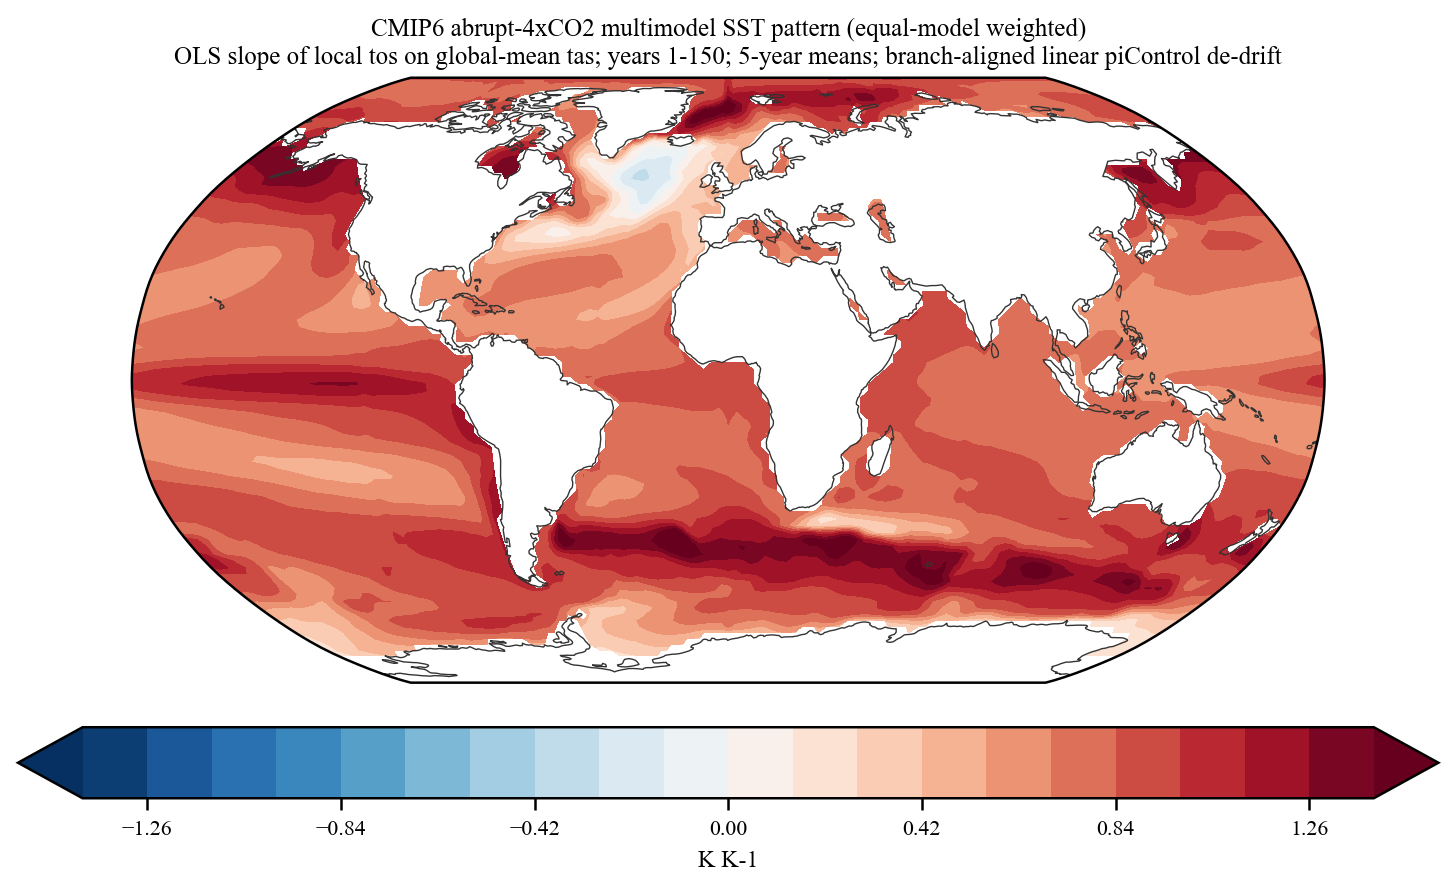

Models in plotted mean: 28; ocean-cell range: 3-28 models


In [35]:
plot_data = sst_pattern_mmm
cyclic_values, cyclic_longitude = add_cyclic_point(
    plot_data.to_numpy(), coord=plot_data["lon"].to_numpy()
)
robust_limit = float(
    np.nanquantile(np.abs(cyclic_values), 0.99)
)
color_limit = max(0.1, np.ceil(robust_limit * 10.0) / 10.0)
levels = np.linspace(-color_limit, color_limit, 21)

fig, ax = plt.subplots(
    figsize=(10.2, 4.8),
    dpi=180,
    subplot_kw={"projection": ccrs.Robinson()},
    constrained_layout=True,
)
contours = ax.contourf(
    cyclic_longitude,
    plot_data["lat"],
    cyclic_values,
    levels=levels,
    cmap="RdBu_r",
    extend="both",
    transform=ccrs.PlateCarree(),
)
ax.coastlines(linewidth=0.55, color="0.2")
ax.set_global()
weight_label = (
    "equal-model weighted"
    if MULTIMODEL_WEIGHTING == "equal"
    else "Kuma code-ancestry weighted"
)
if PATTERN_PREDICTOR == "global_tas":
    pattern_label = "OLS slope of local tos on global-mean tas"
else:
    pattern_label = "OLS time trend of local tos"
drift_label = (
    "branch-aligned linear piControl de-drift"
    if DEDRIFT_ABRUPT else "no piControl drift correction"
)
ax.set_title(
    f"CMIP6 abrupt-4xCO2 multimodel SST pattern ({weight_label})\n"
    f"{pattern_label}; years 1-{ABRUPT_N_YEARS}; "
    f"{TEMPORAL_BIN_YEARS}-year means; {drift_label}",
    fontsize=10,
)
colorbar = fig.colorbar(
    contours,
    ax=ax,
    orientation="horizontal",
    pad=0.06,
    shrink=0.78,
)
colorbar.set_label(sst_pattern_mmm.attrs["units"])
plt.show()

ocean_model_count = sst_pattern_model_count.where(
    ABRUPT_TARGET_OCEAN_MASK.astype(bool)
)
print(
    f"Models in plotted mean: {sst_pattern_by_model.sizes['model']}; "
    f"ocean-cell range: {int(ocean_model_count.min(skipna=True))}-"
    f"{int(ocean_model_count.max(skipna=True))} models"
)

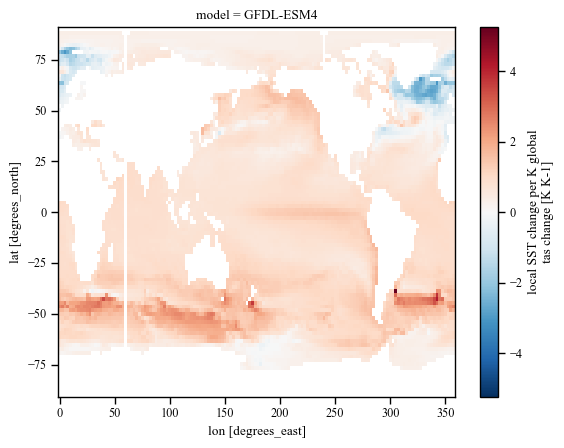

In [41]:
# sst_pattern_by_model.sel(model='CESM2').plot()

sst_pattern_by_model.sel(model='GFDL-ESM4').plot()

### Interpretation notes

- The regression includes an intercept, so absolute model climatology does not affect the slope. With `DEDRIFT_ABRUPT=False`, control drift still can. With it enabled, the code subtracts the linear drift fitted over the exact parent-control segment beginning at `branch_time_in_parent`; nonlinear drift remains uncorrected.
- Controls are required to match the abrupt member's `parent_variant_label`, variable, table, and native `grid_label`. The shared archive and `/glade/campaign/collections/cmip.mirror/.tmp/$USER/CMIP6/CMIP` are both searched. A missing branch segment drops that member (reported in the processing table); a model is excluded in `abrupt_processing_failure_table` only if no usable `tas` or `tos` member remains. The code never substitutes another control period.
- Every `source_id` contributes one model-level pattern. Models with more downloaded ensemble members do not receive more multimodel weight.
- `tas` and `tos` members are averaged independently and aligned by relative experiment year. This targets the forced response but does not preserve member-level internal-variability covariance.
- Bilinear regridding with valid-source-ocean renormalization is performed after temporal averaging and before regression. The destination is the exact fv1.9x2.5 domain grid, and cells with domain land fraction ≥50% are forced to `NaN`; coastal cells below that threshold remain ocean-valid.
- The member cap is applied independently to `tas` and `tos`, using a natural numeric ordering of CMIP variant labels. The two selected variants can differ if a model's first complete member differs by variable. CESM2 is a strict exception: both variables must use `r1i1p1f1`.
- AWI-CM-1-1-MR and INM-CM4-8 are excluded. All `CESM2*` source IDs other than CESM2 itself (including CESM2-FV2) are also excluded.
- Kuma code-ancestry weights account for documented model-code relationships; they are not observational-performance weights and do not make the model ensemble a formal probability distribution.